In [2]:
import torch
import sys

print("Python :", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("CUDA    :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU     :", torch.cuda.get_device_name(0))
    print(
        "VRAM    :",
        round(
            torch.cuda.get_device_properties(0).total_memory
            / 1024**3,
            2
        ),
        "GB"
    )

assert torch.cuda.is_available(), "GPU is not available."

print("\n>> [OK] GPU environment ready.")

Python : 3.11.11
PyTorch: 2.5.1+cu124
CUDA    : True
GPU     : NVIDIA A100-SXM4-80GB
VRAM    : 79.15 GB

>> [OK] GPU environment ready.


## Implementation Pipeline

This notebook implements the complete **Continued Pretraining (CPT) and QLoRA fine-tuning pipeline** for the finance domain.

### Part A: Continued Pretraining

**Finance PDFs**  
↓  
**Step 1 — Data Collection, Extraction and Cleaning**  
8 domain PDFs → page-by-page text extraction → normalization → length filtering → deduplication → English-language filtering → cleaned `.txt` corpus

↓  
**Step 2 — Tokenization and Packed Dataset**  
SmolLM2-360M tokenizer → BOS/EOS document boundaries → token concatenation → 8,192-token packed sequences → Parquet dataset

↓  
**Step 3 — Base Model and Baseline**  
Load SmolLM2-360M → inspect architecture and parameter counts → generate responses for 3 finance-domain prompts before CPT

↓  
**Step 4 — Continued Pretraining (CPT)**  
Convert packed corpus into GPU-compatible 1,024-token training blocks → ~90/10 train/held-out split → full-parameter CPT → capture training loss → analyse loss curve → save CPT model

↓  
**Step 5 — CPT Evaluation**  
Evaluate held-out finance data → calculate perplexity → compare base vs CPT model → repeat the same 3 domain prompts → check general-prompt performance for catastrophic forgetting

---

### Part B — QLoRA Instruction Fine-Tuning

**Cleaned Finance Corpus**  
↓  
**B1 — Instruction Dataset**  
Create grounded instruction-response examples → save JSONL → 80/20 train/evaluation split

↓  
**B2 — QLoRA Fine-Tuning**  
Load model in 4-bit → attach LoRA adapters → supervised fine-tuning using the selected QLoRA configuration

↓  
**B3 — QLoRA Evaluation**  
Run the same finance-domain prompts → compare responses with the base/CPT results → record observations


Assignment mapping:

Steps 1–5 implement Part A (Continued Pretraining), while Steps 6–8 implement Part B (QLoRA Fine-Tuning).

---

## Step 1: Data Collection, Extraction and Cleaning

This step prepares the domain-specific corpus for continued pretraining.

The selected corpus focuses on **Indian Financial Markets and Digital Payments** and consists of publications from SEBI, RBI, and NPCI.

The following stages:
- Retrieve and validate the selected source PDFs.
- Extract text from every PDF page-by-page.
- Inspect the extracted text for extraction quality.
- Normalize whitespace and apply length filtering.
- Remove exact duplicate documents.
- Retain English-language documents.
- Validate the deduplication and language-filtering logic using separate test documents.
- Save the resulting cleaned documents as the final domain corpus.

Document counts before and after each required cleaning operation are reported to measure the effect of the cleaning pipeline.

---

#### Setup and Stage 1: Persistent Folder, Packages and Corpus

Run with the **Python (LLM venv)** kernel. `VOLUME_OVERRIDE` changes the data-volume mount if needed.

**Domain:** Indian Financial Markets and Digital Payments

The corpus was selected to provide two complementary areas of Indian finance:

- **Capital Markets:** SEBI material covering equity derivatives, individual trading behaviour, profitability, and securities buy-backs.
- **Digital Payments:** RBI and NPCI material covering UPI, retail payment statistics, payment systems, and India's payment-system development.

These documents were selected because they are domain-specific publications from Indian financial institutions and contain terminology, regulations, statistics, and financial concepts suitable for continued pretraining.

The corpus contains **8 PDF documents**. This stage retrieves the documents and verifies that all 8 files are available before text extraction begins.

In [3]:
# Setup: persistent folder, packages, corpus
import os, sys, subprocess, importlib.util
from pathlib import Path

# ---- Override field: set to your data-volume mount if it is not /home/05469 ----
VOLUME_OVERRIDE = None        # e.g. "/home/12345"; None = use the default below
DEFAULT_VOLUME = "/home/05469"
# --------------------------------------------------------------------------------

# 1. Work on the persistent data volume (not the temporary /home/jovyan)
VOLUME = Path(VOLUME_OVERRIDE or DEFAULT_VOLUME)
assert VOLUME.exists(), f"Mount not found: {VOLUME}. Set VOLUME_OVERRIDE to your data-volume path (check with: df -h | grep home)."
os.chdir(VOLUME)
assert not str(Path.cwd()).startswith("/home/jovyan"), "Still on temporary home - set VOLUME_OVERRIDE."
print("Working directory:", Path.cwd())

# 2. Kernel check + packages (use the 'Python (LLM venv)' kernel)
from importlib.metadata import version, PackageNotFoundError
print("Python:", sys.executable)
if "venv" not in sys.executable:
    print(">> WARNING: not the venv kernel. Kernel -> Change Kernel -> 'Python (LLM venv)', then restart.")

print("\nPackage check")
for mod, pip_name in {"pymupdf": "pymupdf", "pandas": "pandas", "graphviz": "graphviz",
                      "langdetect": "langdetect", "transformers": "transformers", "pyarrow": "pyarrow"}.items():
    status = "already installed"
    if importlib.util.find_spec(mod) is None:
        print(f"  [..] installing {pip_name} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])
        importlib.invalidate_caches()
        status = "installed now"
    try:
        v = version(pip_name)
    except PackageNotFoundError:
        v = "?"
    print(f"  [OK] {pip_name:<14} {v:<10} ({status})")

# 3. Corpus: clone once, otherwise reuse (or use PDFs you uploaded by hand)
REPO_URL = "https://github.com/devcoderb/llm-assignment-1a-finance-corpus.git"
REPO_DIR = Path.cwd() / "llm-assignment-1a-finance-corpus"
if not REPO_DIR.exists():
    subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(REPO_DIR)], check=False)

PDF_ROOT = REPO_DIR / "data" / "corpus" / "v1" / "Finance"
pdf_files = sorted(p for p in PDF_ROOT.rglob("*.pdf") if "Tests" not in p.parts)
expected_pdf_count = len(pdf_files)
print(f"\nPDFs found: {expected_pdf_count}")
for i, p in enumerate(pdf_files, 1):
    print(f"{i:02d}. {p.relative_to(PDF_ROOT)}")
assert expected_pdf_count > 0, f"No PDFs in {PDF_ROOT} - upload them there if the clone failed."


Working directory: /home/05469
Python: /home/05469/llm-assignment-1a-finance-corpus/venv/bin/python

Package check
  [OK] pymupdf        1.28.2     (already installed)
  [OK] pandas         2.2.3      (already installed)
  [OK] graphviz       0.21       (already installed)
  [OK] langdetect     1.0.9      (already installed)
  [OK] transformers   4.46.3     (already installed)
  [OK] pyarrow        25.0.1     (already installed)

PDFs found: 10
01. Capital Markets/Profitability of Individual Traders in the  Equity Derivatives Segment (FY25–FY26).pdf
02. Capital Markets/SEBI - Buy-Back of Securities.pdf
03. Capital Markets/SEBI Infrastructure Investment Trusts.pdf
04. Capital Markets/SEBI Investor Protection and Education Fund.pdf
05. Capital Markets/SEBI Issue and Listing of Municipal Debt Securities.pdf
06. Capital Markets/Trading Behaviour of Individual Traders in the  Equity Derivatives Segment (FY2025-26).pdf
07. Digital Payments/RBI - Benchmarking Indias Payments Systems - 2022.pd

### Stage 2: Page-Level PDF Extraction with Prose Filter (v3)

**Purpose:** Convert the source finance PDFs into machine-readable text, dropping table/glossary pages and repeated headers/footers.

Per document:
1. **Boilerplate stripping** - lines that repeat (digits ignored) on at least 25% of a document's pages are removed (running headers/footers), as are bare page-number lines.
2. **Exact page dedup** - identical pages (blank/title duplicates) are skipped.
3. **Prose filter** (a page is dropped when):

| Rule | Condition | What it catches |
|------|-----------|-----------------|
| `numeric_heavy` | > 45% of lines are numbers/symbols only **and** < 10 sentences | data grids |
| `short_line_heavy` | > 70% of lines have <= 4 words **and** < 8 sentences | glossaries, label columns |
| `no_prose` | < 2 sentences | pages with no running text |

Sentence-count gating keeps narrow-column pages that are real prose (v2 wrongly dropped e.g. RBI Annual Report p.220).

In [4]:
# Stage 2: Page-level extraction with boilerplate stripping and prose filter
import re, hashlib, collections
import pymupdf
import pandas as pd

EXTRACTED_DIR = Path("domain_corpus/raw")
EXTRACTED_DIR.mkdir(parents=True, exist_ok=True)

NUMERIC_LINE = re.compile(r"^[\d\s.,%()\-–/₹$:+]+$")
PAGE_NO_LINE = re.compile(r"^\s*(\d{1,4}|[ivxlcdm]{1,6})\s*$", re.I)
BOILERPLATE_MIN_PAGES = 6      # skip boilerplate detection for very short documents
BOILERPLATE_FRACTION = 0.25    # line repeated on >= 25% of pages -> header/footer


def norm_line(line: str) -> str:
    return re.sub(r"\d+", "#", re.sub(r"\s+", " ", line.strip().lower()))


def find_boilerplate(page_texts):
    """Lines (digits ignored) repeated on many pages of ONE document = headers/footers."""
    if len(page_texts) < BOILERPLATE_MIN_PAGES:
        return set()
    counts = collections.Counter()
    for t in page_texts:
        counts.update({norm_line(l) for l in t.splitlines() if l.strip()})
    limit = max(4, BOILERPLATE_FRACTION * len(page_texts))
    return {l for l, n in counts.items() if n >= limit and 3 < len(l) < 150}


def strip_page(text, boilerplate):
    kept, removed = [], 0
    for l in text.splitlines():
        if not l.strip():
            kept.append(l); continue
        if PAGE_NO_LINE.match(l) or norm_line(l) in boilerplate:
            removed += 1; continue
        kept.append(l)
    return "\n".join(kept).strip(), removed


def count_sentences(text):
    flat = re.sub(r"\s+", " ", text)
    # split after . ! ? ; followed by space (a decimal like 8.5 has no space, so it is not split)
    parts = re.split(r"(?<=[.!?;])\s+", flat)
    return sum(1 for s in parts if len(s.split()) >= 8 and s.rstrip().endswith((".", "!", "?", ";")))


def score_page(text: str) -> dict:
    """Score one (already boilerplate-stripped) page. Returns signals + keep flag."""
    if not text or len(text.strip()) < 80:
        return {"numeric_ratio": 0, "short_line_ratio": 0, "sentence_count": 0,
                "keep": False, "reason": "too_short"}
    lines = [l for l in text.splitlines() if l.strip()]
    numeric_ratio = sum(bool(NUMERIC_LINE.match(l)) for l in lines) / len(lines)
    short_line_ratio = sum(len(l.split()) <= 4 for l in lines) / len(lines)
    sentence_count = count_sentences(text)

    if numeric_ratio > 0.45 and sentence_count < 10:
        keep, reason = False, "numeric_heavy"
    elif short_line_ratio > 0.70 and sentence_count < 6:
        keep, reason = False, "short_line_heavy"
    elif sentence_count < 2:
        keep, reason = False, "no_prose"
    else:
        keep, reason = True, "pass"
    return {"numeric_ratio": round(numeric_ratio, 3),
            "short_line_ratio": round(short_line_ratio, 3),
            "sentence_count": sentence_count, "keep": keep, "reason": reason}


def page_hash(text: str) -> str:
    return hashlib.md5(re.sub(r"\s+", " ", text.lower().strip()).encode()).hexdigest()


seen_page_hashes: set = set()
extraction_stats, page_filter_log = [], []

for pdf_path in pdf_files:
    doc = pymupdf.open(pdf_path)
    n_pages = len(doc)
    raw_pages = [p.get_text("text").strip() for p in doc]
    doc.close()

    boilerplate = find_boilerplate([t for t in raw_pages if t])
    kept_pages, c = [], collections.Counter()

    for page_number, raw_text in enumerate(raw_pages, start=1):
        if not raw_text:
            c["empty"] += 1
            page_filter_log.append({"document": pdf_path.name, "page": page_number,
                                    "action": "empty", "reason": "empty_page"})
            continue
        ph = page_hash(raw_text)
        if ph in seen_page_hashes:
            c["deduped"] += 1
            page_filter_log.append({"document": pdf_path.name, "page": page_number,
                                    "action": "dedup_drop", "reason": "duplicate_page"})
            continue
        seen_page_hashes.add(ph)

        text, removed = strip_page(raw_text, boilerplate)
        c["boilerplate_lines"] += removed
        score = score_page(text)
        page_filter_log.append({"document": pdf_path.name, "page": page_number,
                                "action": "keep" if score["keep"] else "drop",
                                "reason": score["reason"],
                                "numeric_ratio": score.get("numeric_ratio"),
                                "short_line_ratio": score.get("short_line_ratio"),
                                "sentence_count": score.get("sentence_count")})
        if score["keep"]:
            kept_pages.append(text)
        else:
            c["dropped"] += 1

    full_text = "\n\n".join(kept_pages)
    output_path = EXTRACTED_DIR / f"{pdf_path.stem}.txt"
    output_path.write_text(full_text, encoding="utf-8")

    extraction_stats.append({
        "document": pdf_path.name, "total_pages": n_pages,
        "empty_pages": c["empty"], "deduped_pages": c["deduped"],
        "dropped_pages_filter": c["dropped"], "kept_pages": len(kept_pages),
        "boilerplate_lines_removed": c["boilerplate_lines"],
        "raw_characters": sum(len(t) for t in raw_pages),
        "kept_characters": len(full_text), "output_file": str(output_path),
    })

extraction_df = pd.DataFrame(extraction_stats)
filter_log_df = pd.DataFrame(page_filter_log)

print("Stage 2: PDF Extraction with Page-Level Filter")
print("-" * 55)
display(extraction_df[["document", "total_pages", "empty_pages", "deduped_pages",
                       "dropped_pages_filter", "kept_pages",
                       "boilerplate_lines_removed", "raw_characters", "kept_characters"]])

total_all = len(filter_log_df)
print("\nPage Filter Summary")
print("-------------------")
print(f"Total pages seen         : {total_all:,}")
for act, label in [("empty", "Empty (no text)"), ("dedup_drop", "Duplicate pages"),
                   ("drop", "Dropped (noise/table)"), ("keep", "Kept (prose)")]:
    print(f"  {label:<23}: {(filter_log_df['action'] == act).sum():,}")
kept_n = (filter_log_df["action"] == "keep").sum()
print(f"  Page retention         : {kept_n / max(total_all, 1) * 100:.1f}%")
print(f"  Character retention    : {extraction_df['kept_characters'].sum() / extraction_df['raw_characters'].sum() * 100:.1f}%")
print(f"  Header/footer lines removed: {extraction_df['boilerplate_lines_removed'].sum():,}")

drop_reasons = filter_log_df[filter_log_df["action"] == "drop"]["reason"].value_counts()
if not drop_reasons.empty:
    print("\nDrop reasons (noise filter):")
    for reason, count in drop_reasons.items():
        print(f"  {reason:<25} : {count:,}")

print(f"\n>> [OK] Extraction complete. {len(extraction_df)} documents written to {EXTRACTED_DIR}/")

Stage 2: PDF Extraction with Page-Level Filter
-------------------------------------------------------


,document,total_pages,empty_pages,deduped_pages,dropped_pages_filter,kept_pages,boilerplate_lines_removed,raw_characters,kept_characters
0,Profitability of Individual Traders in the Eq...,91,0,0,21,70,753,171695,139704
1,SEBI - Buy-Back of Securities.pdf,57,0,0,0,57,216,107314,93860
2,SEBI Infrastructure Investment Trusts.pdf,177,0,0,3,174,386,347186,329637
3,SEBI Investor Protection and Education Fund.pdf,8,0,0,0,8,8,20538,20426
4,SEBI Issue and Listing of Municipal Debt Secur...,86,0,0,13,73,89,173348,161676
5,Trading Behaviour of Individual Traders in the...,53,0,0,10,43,338,97662,77391
6,RBI - Benchmarking Indias Payments Systems - 2...,86,0,0,16,70,747,181874,138989
7,RBI - Digitalisation and Payment Revolution in...,36,0,0,2,34,263,108336,103079
8,RBI - Payment and Settlement Systems and Infor...,12,0,0,0,12,118,36157,35180
9,RBI - UPI Annual Report 2025-26.pdf,246,9,12,34,191,2176,692644,579205



Page Filter Summary
-------------------
Total pages seen         : 852
  Empty (no text)        : 9
  Duplicate pages        : 12
  Dropped (noise/table)  : 99
  Kept (prose)           : 732
  Page retention         : 85.9%
  Character retention    : 86.7%
  Header/footer lines removed: 5,094

Drop reasons (noise filter):
  short_line_heavy          : 48
  numeric_heavy             : 39
  no_prose                  : 11
  too_short                 : 1

>> [OK] Extraction complete. 10 documents written to domain_corpus/raw/


In [5]:
# Stage 2A: Filter diagnostic: inspect dropped pages per document

print("Stage 2A: Page Filter Diagnostic")
print("-" * 35)
print()

for doc_name in extraction_df["document"].unique():
    doc_log = filter_log_df[filter_log_df["document"] == doc_name]
    kept = (doc_log["action"] == "keep").sum()
    dropped = (doc_log["action"] == "drop").sum()
    deduped = (doc_log["action"] == "dedup_drop").sum()
    total = len(doc_log)

    print(f"{doc_name[:55]:<55}")
    print(f"   kept={kept}  dropped={dropped}  deduped={deduped}  total={total}")

    # Show the 3 highest-scoring dropped pages for operator review
    dropped_pages = doc_log[
        (doc_log["document"] == doc_name) & (doc_log["action"] == "drop")
    ].head(3)

    if not dropped_pages.empty and "numeric_ratio" in dropped_pages.columns:
        for _, row in dropped_pages.iterrows():
            print(f"     page {row['page']:>4}  reason={row['reason']:<20}", end="")
            if pd.notna(row.get("numeric_ratio")):
                print(f"  numeric={row['numeric_ratio']:.2f}  short_ln={row['short_line_ratio']:.2f}  sents={row['sentence_count']}")
            else:
                print()
    print()

print(">> Tip: If a document has 0 kept pages it will be removed by the length filter.")
print(">> Tune score_page() thresholds if legitimate pages are being dropped.")

Stage 2A: Page Filter Diagnostic
-----------------------------------

Profitability of Individual Traders in the  Equity Deri
   kept=70  dropped=21  deduped=0  total=91
     page    1  reason=no_prose              numeric=0.00  short_ln=0.64  sents=1.0
     page   28  reason=numeric_heavy         numeric=0.46  short_ln=0.79  sents=5.0
     page   34  reason=numeric_heavy         numeric=0.60  short_ln=0.80  sents=0.0

SEBI - Buy-Back of Securities.pdf                      
   kept=57  dropped=0  deduped=0  total=57

SEBI Infrastructure Investment Trusts.pdf              
   kept=174  dropped=3  deduped=0  total=177
     page  131  reason=no_prose              numeric=0.00  short_ln=0.57  sents=1.0
     page  143  reason=no_prose              numeric=0.00  short_ln=0.14  sents=0.0
     page  173  reason=too_short             numeric=0.00  short_ln=0.00  sents=0.0

SEBI Investor Protection and Education Fund.pdf        
   kept=8  dropped=0  deduped=0  total=8

SEBI Issue and Listing of

#### Stage 3: Corpus Cleaning

**Purpose:** Clean the raw extracted text before it is used for continued pretraining.

The cleaning pipeline applies:
1. Whitespace normalization
2. Length filtering
3. Duplicate removal
4. English-language filtering

Document counts are recorded before and after each required cleaning step so the impact of each filter can be evaluated.

In [6]:
# Stage 3A: Whitespace normalization and length filtering

import re

MIN_CHARS = 1000

cleaning_records = []

for row in extraction_stats:
    text_path = Path(row["output_file"])
    text = text_path.read_text(encoding="utf-8")

    original_chars = len(text)

    # Remove excessive spaces/tabs while preserving line structure
    text = re.sub(r"[ \t]+", " ", text)
    # Collapse excessive blank lines
    text = re.sub(r"\n\s*\n+", "\n\n", text)
    text = text.strip()

    cleaning_records.append({
        "document": row["document"],
        "before_chars": original_chars,
        "after_normalization": len(text),
        "passes_length_filter": len(text) >= MIN_CHARS,
        "text": text
    })


cleaning_df = pd.DataFrame(cleaning_records)
print("Stage 3A: White Space Normalisation and Length Filter")
print("-----------------------------------------------------\n")

display(
    cleaning_df[
        ["document", "before_chars",
         "after_normalization", "passes_length_filter"]
    ]
)
print(f"\nDocuments before length filter : {len(cleaning_df)}")
print(f"Documents after length filter  : {cleaning_df['passes_length_filter'].sum()}")

dropped_docs = cleaning_df[~cleaning_df["passes_length_filter"]]["document"].tolist()
if dropped_docs:
    print("\nDropped (too short after page filtering):")
    for d in dropped_docs:
        print(f"  - {d}")
    print("  >> These documents had too many table/noise pages to meet MIN_CHARS.")
    print("  >> Either lower the page filter thresholds or accept the reduction.")

Stage 3A: White Space Normalisation and Length Filter
-----------------------------------------------------



,document,before_chars,after_normalization,passes_length_filter
0,Profitability of Individual Traders in the Eq...,139704,138593,True
1,SEBI - Buy-Back of Securities.pdf,93860,91761,True
2,SEBI Infrastructure Investment Trusts.pdf,329637,321809,True
3,SEBI Investor Protection and Education Fund.pdf,20426,20156,True
4,SEBI Issue and Listing of Municipal Debt Secur...,161676,157438,True
5,Trading Behaviour of Individual Traders in the...,77391,76960,True
6,RBI - Benchmarking Indias Payments Systems - 2...,138989,138602,True
7,RBI - Digitalisation and Payment Revolution in...,103079,102973,True
8,RBI - Payment and Settlement Systems and Infor...,35180,34951,True
9,RBI - UPI Annual Report 2025-26.pdf,579205,577021,True



Documents before length filter : 10
Documents after length filter  : 10


#### Stage 3B: Document-level deduplication

Duplicate documents can unnecessarily repeat the same training data and bias continued pretraining.

This step compares the normalized document contents using a SHA-256 hash. Documents with identical normalized text are treated as duplicates, while the first occurrence is retained.

The document count before and after deduplication is reported.

In [7]:
# Stage 3B: Document-level deduplication
import hashlib

length_filtered = cleaning_df[cleaning_df["passes_length_filter"]].copy()

seen_doc_hashes = set()
deduplicated_records = []

for _, row in length_filtered.iterrows():
    text_hash = hashlib.sha256(row["text"].encode("utf-8")).hexdigest()
    if text_hash not in seen_doc_hashes:
        seen_doc_hashes.add(text_hash)
        deduplicated_records.append(row.to_dict())

deduplicated_df = pd.DataFrame(deduplicated_records)

print("Stage 3B: Document Deduplication")
print("-" * 35)
print(f"Documents before deduplication : {len(length_filtered)}")
print(f"Documents after deduplication  : {len(deduplicated_df)}")
print(f"Duplicates removed             : {len(length_filtered) - len(deduplicated_df)}")

Stage 3B: Document Deduplication
-----------------------------------
Documents before deduplication : 10
Documents after deduplication  : 10
Duplicates removed             : 0


#### Stage 3C: English Language Filtering

The final cleaning step ensures that only English-language documents are retained in the corpus.

The language of each document is detected after normalization and deduplication. Documents identified as English (`en`) are retained, and the document count before and after filtering is reported.

Language detection was performed at document level. Documents whose dominant extracted text was classified as English were retained.

In [8]:
# Stage 3C: English language filtering

from langdetect import detect, DetectorFactory

# Make language detection reproducible
DetectorFactory.seed = 0

language_records = []

for _, row in deduplicated_df.iterrows():
    record = row.to_dict()
    try:
        record["language"] = detect(record["text"])
    except Exception:
        record["language"] = "unknown"
    language_records.append(record)

language_df = pd.DataFrame(language_records)

print("Stage 3C: English Language Filtering")
print("-" * 38)
display(language_df[["document", "language"]])

english_df = language_df[
    language_df["language"] == "en"
].copy()

print(f"\nDocuments before language filter : {len(language_df)}")
print(f"Documents after language filter  : {len(english_df)}")
print(f"Non-English documents removed    : {len(language_df) - len(english_df)}")

Stage 3C: English Language Filtering
--------------------------------------


,document,language
0,Profitability of Individual Traders in the Eq...,en
1,SEBI - Buy-Back of Securities.pdf,en
2,SEBI Infrastructure Investment Trusts.pdf,en
3,SEBI Investor Protection and Education Fund.pdf,en
4,SEBI Issue and Listing of Municipal Debt Secur...,en
5,Trading Behaviour of Individual Traders in the...,en
6,RBI - Benchmarking Indias Payments Systems - 2...,en
7,RBI - Digitalisation and Payment Revolution in...,en
8,RBI - Payment and Settlement Systems and Infor...,en
9,RBI - UPI Annual Report 2025-26.pdf,en



Documents before language filter : 10
Documents after language filter  : 10
Non-English documents removed    : 0


#### Stage 3D: Save Cleaned Corpus and Cleaning Summary

The documents remaining after length filtering, deduplication, and English-language filtering form the final cleaned corpus.

This stage:
- Saves each cleaned document as a `.txt` file in `domain_corpus/`.
- Reports document counts before and after each required cleaning step.
- Calculates the number of documents removed by each step.
- Identifies the cleaning step with the greatest impact on corpus size.

In [11]:
# Stage 3D: Save final cleaned corpus and report cleaning results

FINAL_CORPUS_DIR = Path("domain_corpus")
FINAL_CORPUS_DIR.mkdir(parents=True, exist_ok=True)

# Save final cleaned documents
for _, row in english_df.iterrows():
    output_path = FINAL_CORPUS_DIR / Path(row["document"]).with_suffix(".txt").name
    output_path.write_text(row["text"], encoding="utf-8")

print("Stage 3D: Final Cleaned Corpus")
print("-" * 32)
print(f"Documents saved : {len(english_df)}")
print(f"Output directory: {FINAL_CORPUS_DIR}/")


# Cleaning summary
cleaning_summary = pd.DataFrame([
    {"step": "Length filter",    "before": len(cleaning_df),    "after": len(length_filtered),  "removed": len(cleaning_df) - len(length_filtered)},
    {"step": "Deduplication",    "before": len(length_filtered), "after": len(deduplicated_df), "removed": len(length_filtered) - len(deduplicated_df)},
    {"step": "Language filter",  "before": len(language_df),    "after": len(english_df),      "removed": len(language_df) - len(english_df)},
])

print("\nCleaning Summary")
display(cleaning_summary)

saved_files = sorted(FINAL_CORPUS_DIR.glob("*.txt"))
assert len(saved_files) == len(english_df), "Saved count mismatch."
print(f"\n>> [OK] Final cleaned corpus: {len(saved_files)} documents.")


# Identify greatest impact
max_removed = cleaning_summary["removed"].max()

if max_removed == 0:
    print(
            "Observation: No required cleaning step reduced the corpus "
            
    )
else:
    greatest_steps = cleaning_summary.loc[
        cleaning_summary["removed"] == max_removed,
        "step"
    ].tolist()

    print(f"Greatest impact : {', '.join(greatest_steps)}")
    print(f"Documents removed: {max_removed}")


# Final validation
saved_files = sorted(FINAL_CORPUS_DIR.glob("*.txt"))

assert len(saved_files) == len(english_df), \
    "Saved document count does not match the cleaned corpus."

print(f"\n>> [OK] Final cleaned corpus contains {len(saved_files)} documents.")

Stage 3D: Final Cleaned Corpus
--------------------------------
Documents saved : 10
Output directory: domain_corpus/

Cleaning Summary


,step,before,after,removed
0,Length filter,10,10,0
1,Deduplication,10,10,0
2,Language filter,10,10,0



>> [OK] Final cleaned corpus: 10 documents.
Observation: No required cleaning step reduced the corpus 

>> [OK] Final cleaned corpus contains 10 documents.


## Step 2: Tokenization and Packed Dataset

This step converts the cleaned domain corpus into a training-ready token dataset for continued pretraining.

The pretrained tokenizer associated with **HuggingFaceTB/SmolLM2-360M** is used; no custom tokenizer is trained.

The following stages:
- Load and inspect the pretrained tokenizer.
- Tokenize each cleaned document.
- Add BOS and EOS boundaries around every document.
- Report the total token count and average tokens per document.
- Concatenate the tokenized documents into a continuous token stream.
- Split the stream into fixed-length sequences matching the model's **8,192-token context window**.
- Save the packed sequences in Parquet format for subsequent CPT training.

#### Stage 4: Tokenization and Packed Dataset

The cleaned finance corpus is converted into model tokens using the tokenizer associated with the selected pretrained language model.

A custom tokenizer is not trained. Using the pretrained model's tokenizer ensures that the token IDs produced here are compatible with the model used during continued pretraining.

#### Stage 4A: Load Pretrained Tokenizer

This stage loads the tokenizer and reports its basic configuration before the cleaned documents are tokenized.

#### Model Selection

**Selected model:** `HuggingFaceTB/SmolLM2-360M`

SmolLM2-360M was selected as the base model for thisassignment because it provides a practical balance between model capability and the computational requirements of continued pretraining (CPT) and QLoRA fine-tuning.

The assignment suggests several small causal language models suitable for limited GPU environments. SmolLM2-360M was preferred because:

- **SmolLM2-360M:** Small enough for efficient experimentation while retaining substantially more capacity than very small models. It is suitable for demonstrating both CPT and QLoRA within limited GPU resources.
- **SmolLM2-135M:** Requires fewer resources, but its smaller parameter count provides less model capacity for demonstrating domain adaptation.
- **TinyLlama-1.1B:** Provides greater model capacity, but requires significantly more GPU memory and computation for CPT than the 360M model.
- **Qwen2.5-0.5B:** Is also a viable alternative, but is somewhat larger; SmolLM2-360M provides a lighter CPT workload for this assignment.

Therefore, SmolLM2-360M was selected to keep the complete CPT and QLoRA workflow computationally manageable while still using a non-trivial pretrained causal language model.

**Observation:** For the selected SmolLM2-360M tokenizer, the BOS and EOS tokens are both represented by `<|endoftext|>` (token ID `0`). This is a tokenizer-specific design; the same token is used as a document boundary, with its position indicating the beginning or end of a document.

In [12]:
# Stage 4A: Load pretrained model tokenizer

from transformers import AutoTokenizer

MODEL_NAME = "HuggingFaceTB/SmolLM2-360M"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Stage 4A: Tokenizer Details")
print("-" * 30)
print(f"Model              : {MODEL_NAME}")
print(f"Vocabulary size    : {tokenizer.vocab_size:,}")
print(f"Model max length   : {tokenizer.model_max_length:,}")
print(f"BOS token          : {tokenizer.bos_token!r} (id={tokenizer.bos_token_id})")
print(f"EOS token          : {tokenizer.eos_token!r} (id={tokenizer.eos_token_id})")
print(f"PAD token          : {tokenizer.pad_token!r} (id={tokenizer.pad_token_id})")
print("\n>> [OK] Tokenizer loaded.")

Stage 4A: Tokenizer Details
------------------------------
Model              : HuggingFaceTB/SmolLM2-360M
Vocabulary size    : 49,152
Model max length   : 8,192
BOS token          : '<|endoftext|>' (id=0)
EOS token          : '<|endoftext|>' (id=0)
PAD token          : None (id=None)

>> [OK] Tokenizer loaded.


#### Stage 4B: Tokenize Cleaned Documents

Each cleaned document is tokenized using the pretrained SmolLM2-360M tokenizer.

BOS and EOS token IDs are explicitly added around every document to preserve document boundaries before the documents are concatenated for packing.

This stage also measures the token count of each document and reports the total and average number of tokens in the cleaned corpus.

In [13]:
# Stage 4B: Tokenize cleaned documents with BOS/EOS boundaries

cleaned_files = sorted(FINAL_CORPUS_DIR.glob("*.txt"))

print("Stage 4B: Tokenize Cleaned Documents")
print("-" * 38)
print(f"\nCleaned documents found: {len(cleaned_files)}")
for i, f in enumerate(cleaned_files, 1):
    print(f"  {i:02d}. {f.name}")
print()

tokenized_documents = []
token_stats = []

for file_path in cleaned_files:
    text = file_path.read_text(encoding="utf-8")

    token_ids = (
        [tokenizer.bos_token_id]
        + tokenizer.encode(text, add_special_tokens=False)
        + [tokenizer.eos_token_id]
    )

    tokenized_documents.append(token_ids)

    token_stats.append({
        "document": file_path.name,
        "tokens": len(token_ids),
    })

token_stats_df = pd.DataFrame(token_stats)

print("Token Statistics")
print("-" * 20)
display(token_stats_df)
print(f"\nTotal tokens     : {token_stats_df['tokens'].sum():,}")
print(f"Min doc tokens   : {token_stats_df['tokens'].min():,}")
print(f"Max doc tokens   : {token_stats_df['tokens'].max():,}")
print(f"Mean doc tokens  : {token_stats_df['tokens'].mean():,.0f}")
print("\n>> [OK] All documents tokenized with BOS/EOS boundaries.")

Token indices sequence length is longer than the specified maximum sequence length for this model (43596 > 8192). Running this sequence through the model will result in indexing errors


Stage 4B: Tokenize Cleaned Documents
--------------------------------------

Cleaned documents found: 10
  01. Profitability of Individual Traders in the  Equity Derivatives Segment (FY25–FY26).txt
  02. RBI - Benchmarking Indias Payments Systems - 2022.txt
  03. RBI - Digitalisation and Payment Revolution in India 2024.txt
  04. RBI - Payment and Settlement Systems and Information Technology 2025-26.txt
  05. RBI - UPI Annual Report 2025-26.txt
  06. SEBI - Buy-Back of Securities.txt
  07. SEBI Infrastructure Investment Trusts.txt
  08. SEBI Investor Protection and Education Fund.txt
  09. SEBI Issue and Listing of Municipal Debt Securities.txt
  10. Trading Behaviour of Individual Traders in the  Equity Derivatives Segment (FY2025-26).txt

Token Statistics
--------------------


,document,tokens
0,Profitability of Individual Traders in the Eq...,43598
1,RBI - Benchmarking Indias Payments Systems - 2...,38305
2,RBI - Digitalisation and Payment Revolution in...,29182
3,RBI - Payment and Settlement Systems and Infor...,9910
4,RBI - UPI Annual Report 2025-26.txt,186896
5,SEBI - Buy-Back of Securities.txt,25624
6,SEBI Infrastructure Investment Trusts.txt,86251
7,SEBI Investor Protection and Education Fund.txt,5478
8,SEBI Issue and Listing of Municipal Debt Secur...,39699
9,Trading Behaviour of Individual Traders in the...,20919



Total tokens     : 485,862
Min doc tokens   : 5,478
Max doc tokens   : 186,896
Mean doc tokens  : 48,586

>> [OK] All documents tokenized with BOS/EOS boundaries.


In [14]:
# Stage 4B: Verify and tokenize cleaned documents

cleaned_files = sorted(FINAL_CORPUS_DIR.glob("*.txt"))

print("Stage 4B: Cleaned corpus files on runtime")
print("-----------------------------------------\n")

for i, file_path in enumerate(cleaned_files, 1):
    size_kb = file_path.stat().st_size / 1024
    print(f"{i:02d}. {file_path.name} ({size_kb:,.1f} KB)")

print(f"\nTotal documents: {len(cleaned_files)}")

assert len(cleaned_files) == 10, \
    f"Expected 8 cleaned documents, found {len(cleaned_files)}"

Stage 4B: Cleaned corpus files on runtime
-----------------------------------------

01. Profitability of Individual Traders in the  Equity Derivatives Segment (FY25–FY26).txt (137.0 KB)
02. RBI - Benchmarking Indias Payments Systems - 2022.txt (139.0 KB)
03. RBI - Digitalisation and Payment Revolution in India 2024.txt (101.0 KB)
04. RBI - Payment and Settlement Systems and Information Technology 2025-26.txt (34.3 KB)
05. RBI - UPI Annual Report 2025-26.txt (566.9 KB)
06. SEBI - Buy-Back of Securities.txt (90.1 KB)
07. SEBI Infrastructure Investment Trusts.txt (315.7 KB)
08. SEBI Investor Protection and Education Fund.txt (19.8 KB)
09. SEBI Issue and Listing of Municipal Debt Securities.txt (154.1 KB)
10. Trading Behaviour of Individual Traders in the  Equity Derivatives Segment (FY2025-26).txt (76.4 KB)

Total documents: 10


#### Stage 4C: Create Fixed-Length Packed Sequences

The tokenized documents are concatenated into a single continuous token stream while retaining the BOS/EOS document boundaries added previously.

The combined token stream is then divided into fixed-length sequences matching the selected model's context window of **8,192 tokens**.

Only complete sequences are retained for CPT. Any remaining tokens that cannot form a complete sequence are excluded from the packed training dataset and reported separately.

In [17]:
# Stage 4C: Concatenate and pack tokenized documents

CONTEXT_LENGTH = tokenizer.model_max_length

print("Stage 4C: Packing tokenized corpus")
print("----------------------------------\n")

# Concatenate all tokenized documents into one flat token stream
all_token_ids = [
    token_id
    for document in tokenized_documents
    for token_id in document
]

total_tokens = len(all_token_ids)

# Number of complete context-length sequences
num_sequences = total_tokens // CONTEXT_LENGTH

# Tokens that cannot form a complete sequence
remainder_tokens = total_tokens % CONTEXT_LENGTH

# Create fixed-length packed sequences
packed_sequences = [
    all_token_ids[start:start + CONTEXT_LENGTH]
    for start in range(
        0,
        num_sequences * CONTEXT_LENGTH,
        CONTEXT_LENGTH
    )
]

print("Sequence Packing")
print("-" * 28)
print(f"Context length         : {CONTEXT_LENGTH:,}")
print(f"Total corpus tokens    : {total_tokens:,}")
print(f"Packed sequences       : {len(packed_sequences):,}")
print(f"Tokens in sequences    : {len(packed_sequences) * CONTEXT_LENGTH:,}")
print(f"Remainder tokens       : {remainder_tokens:,}")

# Validate every packed sequence
assert all(len(seq) == CONTEXT_LENGTH for seq in packed_sequences)

print("\n>> [OK] Fixed-length packed sequences created.")

Stage 4C: Packing tokenized corpus
----------------------------------

Sequence Packing
----------------------------
Context length         : 8,192
Total corpus tokens    : 485,862
Packed sequences       : 59
Tokens in sequences    : 483,328
Remainder tokens       : 2,534

>> [OK] Fixed-length packed sequences created.


#### Stage 4D: Save Packed Dataset

The fixed-length packed token sequences are saved in **Parquet** format for use during continued pretraining.

Each row represents one training sequence containing exactly **8,192 token IDs**. Saving the packed dataset separates corpus preparation from model training and allows the prepared dataset to be loaded directly during CPT.

The saved dataset is validated after writing to confirm that the number and length of the stored sequences match the packed data.

In [19]:
# Stage 4D: Save packed sequences to Parquet

PACKED_DATASET_PATH = Path("domain_corpus/packed_dataset.parquet")

packed_df = pd.DataFrame({
    "input_ids": packed_sequences
})

packed_df.to_parquet(
    PACKED_DATASET_PATH,
    index=False
)

saved_packed_df = pd.read_parquet(PACKED_DATASET_PATH)
assert len(saved_packed_df) == len(packed_sequences)
assert all(len(seq) == CONTEXT_LENGTH for seq in saved_packed_df["input_ids"])

print("Stage 4D: Packed Dataset Saved")
print("-" * 32)
print(f"Output file      : {PACKED_DATASET_PATH}")
print(f"Packed sequences : {len(packed_df):,}")
print(f"Sequence length  : {CONTEXT_LENGTH:,}")
print(f"File size        : {PACKED_DATASET_PATH.stat().st_size / (1024**2):.2f} MB")


# Reload the file to verify that it was saved correctly
saved_packed_df = pd.read_parquet(PACKED_DATASET_PATH)

assert len(saved_packed_df) == len(packed_sequences), \
    "Saved sequence count does not match packed sequence count."

assert all(
    len(sequence) == CONTEXT_LENGTH
    for sequence in saved_packed_df["input_ids"]
), "One or more saved sequences have an incorrect length."

print("\n>> [OK] Packed dataset saved and validated.")

Stage 4D: Packed Dataset Saved
--------------------------------
Output file      : domain_corpus/packed_dataset.parquet
Packed sequences : 59
Sequence length  : 8,192
File size        : 0.70 MB

>> [OK] Packed dataset saved and validated.


## Step 3: Model Loading and Architecture

This step loads the pretrained causal language model corresponding to the tokenizer used during dataset preparation.

The model architecture is then inspected to report:
- Total and trainable parameter counts.
- Number of decoder layers.
- Number of attention heads.
- Hidden-state size.
- Attention head dimension.
- Vocabulary size and language-model head output dimension.

The base model will also be evaluated on three finance-domain prompts before continued pretraining to establish a baseline for later comparison.

#### Stage 5A: Load Pretrained Causal Language Model

The pretrained **HuggingFaceTB/SmolLM2-360M** causal language model is loaded using `AutoModelForCausalLM`.

The same model identifier used for the tokenizer is used for the language model, ensuring compatibility between the token IDs produced during corpus preparation and the model's vocabulary.

#### Stage 5A: Compute Environment Check

Before loading the causal language model, the runtime is checked for GPU availability.

The notebook reports the installed PyTorch version, CUDA availability, and the GPU device when available. This helps verify that the environment is suitable for the later CPT and QLoRA training stages.

In [20]:
# Stage 5A: Check compute environment

import torch

print("Stage 5A: Compute Environment")
print("-" * 30)
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA version    : {torch.version.cuda}")
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
    vram = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    print(f"VRAM            : {vram:.2f} GB")
    DEVICE = "cuda"
else:
    DEVICE = "cpu"
    print("Note            : GPU is recommended for CPT and QLoRA training.")

print(f"\nSelected device : {DEVICE}")
print("\n>> [OK] Compute environment checked.")

Stage 5A: Compute Environment
------------------------------
PyTorch version : 2.5.1+cu124
CUDA available  : True
CUDA version    : 12.4
GPU             : NVIDIA A100-SXM4-80GB
VRAM            : 79.15 GB

Selected device : cuda

>> [OK] Compute environment checked.


#### Stage 5B: Load Pretrained Causal Language Model

The pretrained **HuggingFaceTB/SmolLM2-360M** model is loaded with `AutoModelForCausalLM`, using the same model that produced the tokenizer.

**Precision (v3).** `PRECISION_MODE` selects how CPT is run:

- `"fp32_amp"` (default): weights kept in float32, forward/backward in fp16 autocast. A T4 has no native bf16, and in pure-bf16 training at lr 2e-5 many weight updates are smaller than bf16 resolution and are rounded away.
- `"bf16"`: weights in bfloat16 exactly as the assignment brief suggests. Use this to reproduce the v1/v2 setting for an A/B comparison.

If `fp32_amp` produces NaN loss, switch to `"bf16"`. Gradient checkpointing is enabled in both modes, as the assignment requires.

In [21]:
# Stage 5B: Load pretrained causal language model

import torch
from transformers import AutoModelForCausalLM

PRECISION_MODE = "fp32_amp"          # "fp32_amp" or "bf16"
MODEL_DTYPE = torch.float32 if PRECISION_MODE == "fp32_amp" else torch.bfloat16

print("Stage 5B: Loading pretrained causal language model...")

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=MODEL_DTYPE
).to(DEVICE)

model.gradient_checkpointing_enable()
model.config.use_cache = False       # required while gradient checkpointing is on
model.train()

print(f"\nPrecision mode          : {PRECISION_MODE}")
print(f"Weight dtype            : {next(model.parameters()).dtype}")
print(f"Gradient checkpointing  : {model.is_gradient_checkpointing}")
print(f"\n>> [OK] {MODEL_NAME} loaded on {DEVICE}.")

Stage 5B: Loading pretrained causal language model...

Precision mode          : fp32_amp
Weight dtype            : torch.float32
Gradient checkpointing  : True

>> [OK] HuggingFaceTB/SmolLM2-360M loaded on cuda.


### Stage 5C: Model Architecture and Parameter Analysis

The loaded pretrained model is inspected programmatically to report its architecture and parameter counts.

The following properties are recorded:
- Total number of model parameters.
- Number of trainable parameters.
- Number of decoder layers.
- Number of attention heads.
- Hidden-state size.
- Attention head dimension.
- Model vocabulary size.
- Language-model (`lm_head`) output dimension.

The attention head dimension is calculated as:

> **Head Dimension = Hidden Size / Number of Attention Heads**

For the base pretrained model, all parameters are expected to be trainable before any parameter-efficient fine-tuning configuration is applied.

In [22]:
# Stage 5C: Inspect model architecture and parameter counts

config = model.config

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
num_layers = config.num_hidden_layers
num_heads = config.num_attention_heads
hidden_size = config.hidden_size
head_dim = hidden_size // num_heads
vocab_size = config.vocab_size
lm_head_output = model.lm_head.out_features

print("Stage 5C: Model Architecture")
print("-" * 30)
print(f"Total parameters       : {total_params:,}")
print(f"Trainable parameters   : {trainable_params:,}")
print(f"Decoder layers         : {num_layers}")
print(f"Attention heads        : {num_heads}")
print(f"Hidden size            : {hidden_size}")
print(f"Head dimension         : {head_dim}")
print(f"Vocabulary size        : {vocab_size:,}")
print(f"LM head output         : {lm_head_output:,}")

assert vocab_size == lm_head_output, "LM head output does not match vocab size!"
print("\n>> [OK] Model architecture validated.")

Stage 5C: Model Architecture
------------------------------
Total parameters       : 361,821,120
Trainable parameters   : 361,821,120
Decoder layers         : 32
Attention heads        : 15
Hidden size            : 960
Head dimension         : 64
Vocabulary size        : 49,152
LM head output         : 49,152

>> [OK] Model architecture validated.


#### Architecture Calculations and Inference
--------------------------------------------

The architecture values above are obtained directly from the pretrained model configuration and parameters.

**1. Total Parameters**

The model contains:

> 361,821,120 parameters ≈ 361.8 million ≈ 360M

The name **SmolLM2-360M** therefore represents the approximate parameter scale of the model rather than an exact parameter count.

**2. Trainable Parameters**

A parameter is considered trainable when it is allowed to be updated during training (`requires_grad = True`).

> Trainable Parameters = Sum of all parameters where `requires_grad = True`

For the currently loaded base model:

> Trainable Parameters = 361,821,120

Since no model parameters have been frozen:

> Trainable % = (Trainable Parameters / Total Parameters) × 100

> Trainable % = (361,821,120 / 361,821,120) × 100 = 100%

Therefore, all parameters of the base model are currently trainable. Later, parameter-efficient methods such as QLoRA will train only a small subset of additional adapter parameters while keeping the base model frozen.

**3. Decoder Layers**

The model configuration specifies:

> Number of Decoder Layers = 32

The input representations pass sequentially through these 32 transformer decoder layers during causal language modelling.

**4. Attention Heads**

Each decoder layer uses:

> Number of Attention Heads = 15

These attention heads allow the model to represent multiple attention patterns within each decoder layer.

**5. Hidden Size**

The model configuration specifies:

> Hidden Size = 960

This means that the main hidden representation for each token contains 960 values.

**6. Attention Head Dimension**

The dimension handled by each attention head is:

> Head Dimension = Hidden Size / Number of Attention Heads

> Head Dimension = 960 / 15 = 64

Therefore, each of the 15 attention heads operates with a head dimension of 64.

**7. Vocabulary Size**

The model vocabulary contains:

> Vocabulary Size = 49,152 tokens

This matches the vocabulary reported by the SmolLM2 tokenizer used during corpus preparation.

**8. Language-Model Head Output**

The final language-model head has:

> LM Head Output Dimension = 49,152

This matches the vocabulary size:

> LM Head Output Dimension = Vocabulary Size = 49,152

Therefore, for each prediction position, the model produces **49,152 logits** — one score for every possible token in its vocabulary. These scores are used to determine the probability distribution for the next token.

--------------------------------------------

**Overall Observation:** The architecture values confirm that the correct pretrained causal language model has been loaded and that its vocabulary is compatible with the tokenizer used to prepare the packed finance corpus.

#### Stage 5D: Baseline Domain Inference

Before continued pretraining, the base SmolLM2-360M model is run on finance prompts. Six prompts are used: the three assignment-style instruction prompts, plus three **completion-style** prompts that suit a base (non-instruct) model better.

**Generation settings (v3).** One shared `GENERATE_KWARGS` is used for every model stage (Base, CPT, QLoRA): greedy decoding (deterministic, so outputs are directly comparable), `repetition_penalty=1.1` (mild, so domain words are not suppressed) and `no_repeat_ngram_size=4` (blocks verbatim loops).

These responses are the pre-CPT baseline for later comparison.

In [23]:
# Stage 5D: Baseline inference before CPT

# Shared by Stage 5D, 7D, 7E and 10A so Base / CPT / QLoRA are compared fairly.
GENERATE_KWARGS = dict(
    max_new_tokens=150,
    do_sample=False,            # deterministic -> reproducible comparison
    repetition_penalty=1.1,     # mild: does not suppress domain vocabulary
    no_repeat_ngram_size=4,     # blocks verbatim loops
)

def generate_text(m, tok, text):
    inputs = tok(text, return_tensors="pt").to(m.device)
    with torch.no_grad():
        out = m.generate(**inputs, **GENERATE_KWARGS,
                         use_cache=True, pad_token_id=tok.eos_token_id)
    return tok.decode(out[0, inputs["input_ids"].shape[1]:],
                      skip_special_tokens=True).strip()

domain_prompts = [
    "Explain the risks faced by individual traders in equity derivatives markets.",
    "Explain how UPI has contributed to the growth of digital payments in India.",
    "What is a buy-back of securities and why might a company conduct one?",
]
completion_prompts = [
    "According to SEBI's study, the majority of individual traders in the equity derivatives segment",
    "The Unified Payments Interface (UPI) has transformed retail payments in India by",
    "Under SEBI regulations, a company may buy back its shares from existing shareholders through",
]
all_domain_prompts = domain_prompts + completion_prompts

baseline_outputs = []
model.eval()

print("Stage 5D: Baseline Inference Before CPT")
print("-" * 40)
print(f"Generation: {GENERATE_KWARGS}\n")

for i, prompt in enumerate(all_domain_prompts, 1):
    response = generate_text(model, tokenizer, prompt)
    baseline_outputs.append({"prompt": prompt, "response": response})
    print(f"Prompt {i}\n>> {prompt}\n\nBase model response:\n{response}\n" + "-" * 70)

print("\n>> [OK] Baseline responses captured.")

Stage 5D: Baseline Inference Before CPT
----------------------------------------
Generation: {'max_new_tokens': 150, 'do_sample': False, 'repetition_penalty': 1.1, 'no_repeat_ngram_size': 4}

Prompt 1
>> Explain the risks faced by individual traders in equity derivatives markets.

Base model response:
The risk of a trader is that he will lose money on his position, and this can be due to many reasons such as:

  • The price of the underlying asset changes
  • A change in market sentiment or investor confidence
  • An unexpected event (such as an earthquake) which causes investors to sell their positions at a loss
  • A sudden increase in interest rates causing the value of the derivative to fall
  • A company going bankrupt or being taken over by another company
  • A government bailout for a failing company
  • Changes in regulations affecting the trading of derivatives

Risk management strategies are used to reduce these risks. For example, if you have a long-term position in a stock

#### Baseline Inference Observation

The base model (SmolLM2-360M, before CPT) was run on six prompts: three instruction-style and three completion-style. Decoding is fixed (greedy, `repetition_penalty=1.1`, `no_repeat_ngram_size=4`) and is reused for the CPT and QLoRA outputs so all three stages are directly comparable.

- **Fluency:** Responses are fluent and on topic, with no looping.
- **Equity derivatives (instruction):** A reasonable list of generic market risks, with nothing specific to Indian retail traders or SEBI findings.
- **UPI (instruction):** Correctly links UPI to easier digital payments but contains factual errors, such as describing it as "open-source" and "adopted by over 95% of the population".
- **Buy-back (instruction):** The definition is broadly correct, but the answer drifts into generic questions and gives an unsupported worked example.
- **SEBI study completion:** The statistics given are vague and not traceable to the study.
- **UPI completion:** The answer drifts to Flipkart and Amazon e-commerce rather than UPI's effect on retail payments.
- **SEBI buy-back completion:** Describes buy-back routes as an IPO or a market sale and cites the SEC, instead of SEBI's tender offer, open market and book building routes.

Overall, the baseline is fluent but generic and sometimes wrong on India-specific finance details. CPT is therefore expected to show mainly as lower held-out perplexity, not a large change in fluency.

## Step 4: Continued Pretraining and Loss Tracking

The pretrained SmolLM2-360M model is adapted to the finance domain using continued pretraining (CPT) on the packed token dataset prepared in Step 2.

During CPT:
- The packed Parquet dataset is loaded into a PyTorch Dataset.
- Training hyperparameters are configured.
- The model is trained using causal language modelling.
- Training loss is captured at each logging step using a custom `TrainerCallback`.
- Loss is plotted against training steps to analyse convergence.
- The final CPT model and tokenizer are saved for subsequent evaluation.

The objective is to adapt the existing pretrained model to the terminology and statistical patterns present in the selected finance corpus rather than training a language model from scratch.

#### Stage 6A: Build CPT Training and Held-Out Datasets

The packed Parquet from Step 2 remains the Step-2 deliverable. For CPT, the tokenized documents are split **inside each document**: the last 10% of every document's tokens become the held-out stream, and the 1,024 tokens before the cut are dropped from training so training and held-out text are not adjacent. Each stream is then cut into fixed 1,024-token blocks.

v1/v2 split random 1,024-token blocks, so held-out text sat next to training text from the same page (an estimated ~15% of held-out 8-word phrases also appeared verbatim in training).

In [24]:
# Stage 6A: Build CPT train / held-out datasets with a leakage-safe split
from torch.utils.data import Dataset

CPT_SEQUENCE_LENGTH = 1024
HOLDOUT_RATIO = 0.10
SPLIT_GAP_TOKENS = 1024
RANDOM_SEED = 42


def split_documents(docs, holdout_ratio, gap, bos_id, eos_id):
    """Per document: head -> train stream, tail -> held-out stream, gap dropped."""
    train_stream, held_stream = [], []
    for d in docs:
        body = d[1:-1]                       # strip BOS/EOS added in Stage 4B
        cut = int(len(body) * (1 - holdout_ratio))
        train_stream += [bos_id] + body[:max(cut - gap, 0)] + [eos_id]
        held_stream += [bos_id] + body[cut:] + [eos_id]
    return train_stream, held_stream


def to_blocks(stream, length):
    return [stream[i:i + length] for i in range(0, len(stream) - length + 1, length)]


class CPTDataset(Dataset):
    def __init__(self, blocks):
        self.sequences = blocks

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        import torch
        ids = torch.tensor(self.sequences[idx], dtype=torch.long)
        return {"input_ids": ids, "labels": ids.clone()}


train_stream, held_stream = split_documents(
    tokenized_documents, HOLDOUT_RATIO, SPLIT_GAP_TOKENS,
    tokenizer.bos_token_id, tokenizer.eos_token_id)

cpt_train_dataset = CPTDataset(to_blocks(train_stream, CPT_SEQUENCE_LENGTH))
cpt_holdout_dataset = CPTDataset(to_blocks(held_stream, CPT_SEQUENCE_LENGTH))

print("Stage 6A: CPT Datasets")
print("-" * 25)
print(f"Step-2 packed length   : {CONTEXT_LENGTH:,}")
print(f"CPT sequence length    : {CPT_SEQUENCE_LENGTH:,}")
print(f"Training blocks        : {len(cpt_train_dataset):,}")
print(f"Held-out blocks        : {len(cpt_holdout_dataset):,}")
sample = cpt_train_dataset[0]
print(f"Input shape            : {tuple(sample['input_ids'].shape)}")
print(f"Label shape            : {tuple(sample['labels'].shape)}")
print("\n>> [OK] PyTorch CPT datasets ready.")

Stage 6A: CPT Datasets
-------------------------
Step-2 packed length   : 8,192
CPT sequence length    : 1,024
Training blocks        : 417
Held-out blocks        : 47
Input shape            : (1024,)
Label shape            : (1024,)

>> [OK] PyTorch CPT datasets ready.


#### CPT Dataset Observation

The cleaned corpus was packed into 8,192-token sequences, then cut into 1,024-token blocks for CPT. This produced 464 blocks in total: 417 for training and 47 held out for evaluation.

Each block has an input sequence and a label sequence of the same length (1,024 tokens). Labels are the inputs shifted for next-token prediction, which is the standard causal language modelling setup.

The dataset is small, about 0.43M training tokens, so CPT is expected to adapt the model gently. The held-out blocks come from the end of each document, so they measure how well the model handles unseen passages and not memorized text.

#### Stage 6B: Validate the Held-Out Split

The held-out blocks must not be seen during CPT. This stage reports split sizes and measures **verbatim overlap**: the share of held-out 16-token windows that also occur in the training blocks. Repeated regulatory boilerplate means it will not be exactly zero, but it should be small.

In [25]:
# Stage 6B: Validate split sizes and verbatim overlap

def windows(blocks, n=16, step=4):
    out = set()
    for b in blocks:
        for i in range(0, len(b) - n + 1, step):
            out.add(tuple(b[i:i + n]))
    return out

train_windows = windows(cpt_train_dataset.sequences, step=1)
held_windows = windows(cpt_holdout_dataset.sequences, step=4)
overlap = len(held_windows & train_windows) / max(len(held_windows), 1)

total_blocks = len(cpt_train_dataset) + len(cpt_holdout_dataset)
print("Stage 6B: CPT Dataset Split")
print("-" * 30)
print(f"Total blocks         : {total_blocks:,}")
print(f"Training blocks      : {len(cpt_train_dataset):,} ({len(cpt_train_dataset)/total_blocks:.1%})")
print(f"Held-out blocks      : {len(cpt_holdout_dataset):,} ({len(cpt_holdout_dataset)/total_blocks:.1%})")
print(f"Training tokens      : {len(cpt_train_dataset) * CPT_SEQUENCE_LENGTH:,}")
print(f"Held-out tokens      : {len(cpt_holdout_dataset) * CPT_SEQUENCE_LENGTH:,}")
print(f"Held-out 16-token windows also in training: {overlap:.1%}")
print("\n>> [OK] Training and held-out datasets validated.")

Stage 6B: CPT Dataset Split
------------------------------
Total blocks         : 464
Training blocks      : 417 (89.9%)
Held-out blocks      : 47 (10.1%)
Training tokens      : 427,008
Held-out tokens      : 48,128
Held-out 16-token windows also in training: 2.4%

>> [OK] Training and held-out datasets validated.


#### CPT Split Observation

The corpus was split by holding out the last 10% of each document, with a 1,024-token gap between the training and held-out text. This gave 417 training blocks (427,008 tokens) and 47 held-out blocks (48,128 tokens), a 89.9% / 10.1% split.

A 16-token-window check found 2.4% of held-out windows also present in training. These are most likely shared regulatory phrasing and the two related SEBI trader studies, not copied passages. This is much lower than the roughly 15% overlap from the earlier random block split, so held-out perplexity is only slightly optimistic.

#### Stage 6C: Configure CPT Training and Loss Tracking

The continued-pretraining configuration defines how the base model is adapted to the finance corpus.

- **Data:** 417 training blocks of 1,024 tokens. The 47 held-out blocks are excluded from training and reserved for perplexity evaluation.
- **Optimisation:** learning rate 5e-5 with a cosine schedule and 3% warmup, 2 epochs, batch size 1 with gradient accumulation of 4 (effective batch 4).
- **Precision and memory:** fp32 weights with bf16 autocast on an NVIDIA A100 80 GB, and gradient checkpointing to reduce memory.

A custom `TrainerCallback` records the training loss at each logging step. These values are later plotted as training loss against training step, to check whether CPT loss converges or plateaus.

In [26]:
# Stage 6C: Configure CPT training and loss tracking

from transformers import TrainingArguments, TrainerCallback

CPT_OUTPUT_DIR = "cpt_output"

NUM_EPOCHS = 2
LEARNING_RATE = 5e-5           # v1/v2 used 2e-5
WARMUP_RATIO = 0.03
BATCH_SIZE = 1
GRADIENT_ACCUMULATION_STEPS = 4
LOGGING_STEPS = 1


class LossHistoryCallback(TrainerCallback):
    def __init__(self):
        self.steps = []
        self.losses = []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs and "loss" in logs:
            self.steps.append(state.global_step)
            self.losses.append(logs["loss"])


loss_callback = LossHistoryCallback()

# bf16 autocast on GPUs with native bf16 (A100/L40S: compute capability >= 8), fp16 autocast otherwise (T4)
native_bf16 = torch.cuda.is_available() and torch.cuda.get_device_capability()[0] >= 8
use_bf16 = torch.cuda.is_available() and (PRECISION_MODE == "bf16" or (PRECISION_MODE == "fp32_amp" and native_bf16))
use_fp16 = torch.cuda.is_available() and PRECISION_MODE == "fp32_amp" and not native_bf16

training_args = TrainingArguments(
    output_dir=CPT_OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    learning_rate=LEARNING_RATE,
    warmup_ratio=WARMUP_RATIO,
    lr_scheduler_type="cosine",
    gradient_checkpointing=True,
    logging_steps=LOGGING_STEPS,
    save_strategy="no",
    bf16=use_bf16,
    fp16=use_fp16,
    report_to="none",
    seed=RANDOM_SEED,
)

model.train()

print("Stage 6C: CPT Training Configuration")
print("-" * 40)
print(f"Training sequences      : {len(cpt_train_dataset):,}")
print(f"Held-out sequences      : {len(cpt_holdout_dataset):,}")
print(f"Epochs                  : {NUM_EPOCHS}")
print(f"Batch size              : {BATCH_SIZE}")
print(f"Gradient accumulation   : {GRADIENT_ACCUMULATION_STEPS}")
print(f"Effective batch size    : {BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS}")
print(f"Learning rate           : {LEARNING_RATE}")
print(f"Warmup ratio            : {WARMUP_RATIO}")
print(f"Precision mode          : {PRECISION_MODE}")
print(f"BF16                    : {use_bf16}")
print(f"FP16                    : {use_fp16}")
print("\n>> [OK] CPT training configuration ready.")

Stage 6C: CPT Training Configuration
----------------------------------------
Training sequences      : 417
Held-out sequences      : 47
Epochs                  : 2
Batch size              : 1
Gradient accumulation   : 4
Effective batch size    : 4
Learning rate           : 5e-05
Warmup ratio            : 0.03
Precision mode          : fp32_amp
BF16                    : True
FP16                    : False

>> [OK] CPT training configuration ready.


#### Training Configuration Observation

CPT uses the 417 training blocks and keeps the 47 held-out blocks out of training for perplexity evaluation.

- **Batch:** batch size 1 with gradient accumulation of 4 gives an effective batch of 4 blocks (4,096 tokens) per optimizer step. This is about 104 steps per epoch and about 208 over 2 epochs.
- **Learning rate:** 5e-5 with a cosine schedule and 3% warmup. This is high enough to adapt the model to the corpus but low enough to limit forgetting of general knowledge.
- **Precision:** fp32 weights with bf16 autocast (`fp32_amp`). Keeping the weights in fp32 means small updates are not rounded away, as can happen with pure bf16 weights at this learning rate.
- **Epochs:** 2, which suits a corpus of about 0.43M training tokens. More epochs would risk memorizing the text instead of adapting to the domain.

Training loss will be logged at each logging step and plotted against step to check for convergence or a plateau.

#### Stage 6D: Run Continued Pretraining

The pretrained SmolLM2-360M model is now trained on the finance-domain training split using Hugging Face `Trainer`.

Only the **417 CPT training blocks** are supplied to the trainer. The **47 held-out blocks are not used during training** and remain reserved for later perplexity evaluation.

During training, the custom `LossHistoryCallback` records the loss at every logging step. These values are later plotted to analyse the model's learning behaviour and to check whether the training loss reaches a plateau.

The run uses the CUDA GPU detected earlier (an A100 80 GB). Mixed precision is selected automatically from the GPU's capabilities, which gives bf16 autocast with fp32 weights here.

In [27]:
# Stage 6D: Create Trainer and run CPT

from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=cpt_train_dataset,
    callbacks=[loss_callback]
)

print("Stage 6D: Continued Pretraining (CPT)")
print("-" * 40)
print(f"Device             : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU                : {torch.cuda.get_device_name(0)}")
print(f"Training sequences : {len(cpt_train_dataset):,}")
print(f"Held-out sequences : {len(cpt_holdout_dataset):,}")
print(f"Epochs             : {NUM_EPOCHS}")
print(f"Learning rate      : {LEARNING_RATE}")
print("\nStarting CPT...\n")

train_result = trainer.train()

print("\nCPT complete.")

Stage 6D: Continued Pretraining (CPT)
----------------------------------------
Device             : cuda
GPU                : NVIDIA A100-SXM4-80GB
Training sequences : 417
Held-out sequences : 47
Epochs             : 2
Learning rate      : 5e-05

Starting CPT...



Step,Training Loss
1,2.003600
2,1.637100
3,2.435200
4,2.197500
5,2.180600
6,1.830700
7,1.836900
8,1.979900
9,2.131000
10,2.070200



CPT complete.


CPT Loss Summary
--------------------
Logged steps           : 208
First loss             : 2.0036
Final loss             : 1.4965
Minimum loss           : 1.2409
Mean loss              : 1.7333
First-half mean        : 1.8658
Second-half mean       : 1.6009


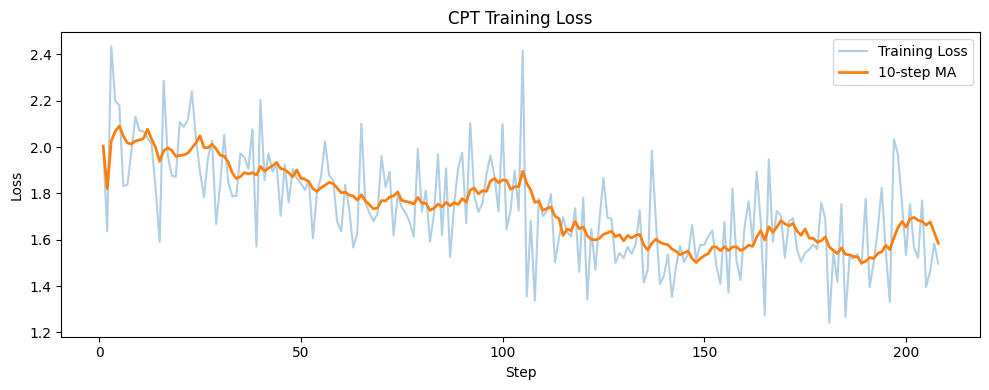

>> Loss plot saved: cpt_loss_v2.png


In [28]:
# Stage 6E: Dynamic CPT loss summary

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

loss_values = [e["loss"] for e in trainer.state.log_history if "loss" in e]

half = len(loss_values) // 2

print("CPT Loss Summary")
print("-" * 20)
print(f"Logged steps           : {len(loss_values):,}")
print(f"First loss             : {loss_values[0]:.4f}")
print(f"Final loss             : {loss_values[-1]:.4f}")
print(f"Minimum loss           : {min(loss_values):.4f}")
print(f"Mean loss              : {np.mean(loss_values):.4f}")
print(f"First-half mean        : {np.mean(loss_values[:half]):.4f}")
print(f"Second-half mean       : {np.mean(loss_values[half:]):.4f}")

loss_df = pd.DataFrame({"step": loss_callback.steps, "loss": loss_callback.losses})
loss_df["ma"] = loss_df["loss"].rolling(window=10, min_periods=1).mean()

plt.figure(figsize=(10, 4))
plt.plot(loss_df["step"], loss_df["loss"], alpha=0.35, label="Training Loss")
plt.plot(loss_df["step"], loss_df["ma"], linewidth=2, label="10-step MA")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("CPT Training Loss")
plt.legend()
plt.tight_layout()
plt.savefig("cpt_loss_v2.png", dpi=120)
plt.show()
print(">> Loss plot saved: cpt_loss_v2.png")

#### CPT Loss Observation

Training ran for 208 steps (2 epochs) in about 2 minutes. The loss started at 2.00 and ended at 1.50, with a minimum of 1.24 and an overall mean of 1.73. The first-half mean was 1.87 and the second-half mean 1.60.

The 10-step moving average falls from about 2.0 to about 1.5 and flattens in the second epoch. There is a visible step down at the start of epoch 2 (around step 105), when the model sees the training blocks for the second time. Part of this drop reflects exposure to repeated training text, so training loss alone is not evidence of generalisation. The step-to-step noise is expected, since each step averages only 4 blocks of 1,024 tokens. The small rise near the end is noise from a few difficult blocks while the learning rate decays.

The loss shows no divergence or NaN values. Whether CPT improved the model on unseen text is judged by held-out perplexity in the next stage.

### Stage 6F: Save the CPT Model

The model obtained after continued pretraining is saved together with its tokenizer.

Saving the CPT checkpoint preserves the finance-adapted model for subsequent evaluation and QLoRA fine-tuning without requiring the CPT training process to be repeated.

In [29]:
# Stage 6F: Save CPT model and tokenizer

CPT_MODEL_DIR = Path("cpt_model")

print("Stage 6F: Saving CPT Model")
print("-" * 28)

model.save_pretrained(CPT_MODEL_DIR)
tokenizer.save_pretrained(CPT_MODEL_DIR)

assert CPT_MODEL_DIR.exists()
assert (CPT_MODEL_DIR / "config.json").exists()

print(f"Saved to : {CPT_MODEL_DIR}/")
print("\n>> [OK] CPT model and tokenizer saved.")

Stage 6F: Saving CPT Model
----------------------------
Saved to : cpt_model/

>> [OK] CPT model and tokenizer saved.


## Step 5: CPT Evaluation

This step evaluates whether continued pretraining improved the model's adaptation to the finance domain.

The evaluation includes:

- Computing perplexity on the held-out finance-domain sequences that were excluded from CPT.
- Comparing the **base SmolLM2-360M model** against the **CPT-adapted model** on the same held-out data.
- Re-running the same three finance-domain prompts used before CPT and comparing the generated responses.
- Testing general-purpose prompts before and after CPT to identify possible catastrophic forgetting.

A lower held-out perplexity after CPT indicates improved predictive fit to the finance-domain corpus.

#### Stage 7A: Held-Out Perplexity Evaluation

Perplexity measures how well a language model predicts unseen text. It is calculated as the exponential of the average negative log-likelihood.

Both the original pretrained model and the CPT-adapted model are evaluated on the same held-out finance-domain sequences to provide a direct comparison.

Lower perplexity indicates better predictive performance on the held-out finance-domain text.

In [30]:
# Stage 7A: Perplexity evaluation function

import math
import torch


def calculate_perplexity(model, dataset, device):
    model.eval()

    total_loss = 0.0
    total_tokens = 0

    with torch.no_grad():
        for sample in dataset:
            input_ids = sample["input_ids"].unsqueeze(0).to(device)
            labels = sample["labels"].unsqueeze(0).to(device)

            outputs = model(
                input_ids=input_ids,
                labels=labels
            )

            # Causal LM loss predicts tokens 1...N from tokens 0...N-1
            predicted_tokens = labels.numel() - 1

            total_loss += outputs.loss.item() * predicted_tokens
            total_tokens += predicted_tokens

    average_nll = total_loss / total_tokens
    perplexity = math.exp(average_nll)

    return average_nll, perplexity


print("Stage 7A: Held-Out Evaluation Setup")
print("-" * 38)
print(f"Held-out sequences : {len(cpt_holdout_dataset)}")
print(f"Sequence length    : {CPT_SEQUENCE_LENGTH:,}")
print(
    f"Evaluation tokens  : "
    f"{len(cpt_holdout_dataset) * (CPT_SEQUENCE_LENGTH - 1):,}"
)

print("\n>> [OK] Perplexity evaluation function ready.")

Stage 7A: Held-Out Evaluation Setup
--------------------------------------
Held-out sequences : 47
Sequence length    : 1,024
Evaluation tokens  : 48,081

>> [OK] Perplexity evaluation function ready.


### Stage 7B: CPT Model Perplexity

The CPT model is evaluated on the 47 held-out blocks (48,081 prediction tokens) that were never used in training. Perplexity is the exponential of the average negative log-likelihood per token, so a lower value means the model predicts unseen domain text better. The same function is used for the base model in Stage 7C so the two scores are directly comparable.

In [31]:
# Stage 7B: Evaluate CPT model perplexity

model.to(DEVICE)

cpt_nll, cpt_perplexity = calculate_perplexity(model, cpt_holdout_dataset, DEVICE)

print("Stage 7B: CPT Model Perplexity")
print("-" * 32)
print(f"Average NLL : {cpt_nll:.4f}")
print(f"Perplexity  : {cpt_perplexity:.4f}")
print("\n>> [OK] CPT model evaluation completed.")

Stage 7B: CPT Model Perplexity
--------------------------------
Average NLL : 1.8920
Perplexity  : 6.6324

>> [OK] CPT model evaluation completed.


#### CPT Perplexity Observation

On the 47 held-out blocks (48,081 prediction tokens), the CPT model reached a perplexity of 6.63 (average NLL 1.892).

### Stage 7C: Base Model Perplexity

The original pretrained SmolLM2-360M model is evaluated on the **same held-out finance-domain sequences** used for the CPT model.

Using identical evaluation data provides a direct comparison between the original base model and the finance-adapted CPT model. A lower perplexity for the CPT model would indicate improved predictive fit to the held-out finance-domain corpus.

In [32]:
# Stage 7C: Evaluate base model perplexity

import gc
from transformers import AutoModelForCausalLM

model.to("cpu")
gc.collect()
torch.cuda.empty_cache()

print("Stage 7C: Base Model Perplexity")
print("-" * 33)
print("Loading original pretrained model...\n")

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, torch_dtype=MODEL_DTYPE
).to(DEVICE)

base_nll, base_perplexity = calculate_perplexity(base_model, cpt_holdout_dataset, DEVICE)

ppl_change = base_perplexity - cpt_perplexity
ppl_pct = ppl_change / base_perplexity * 100

print("Perplexity Comparison")
print("-" * 30)
print(f"Base model PPL : {base_perplexity:.4f}")
print(f"CPT model PPL  : {cpt_perplexity:.4f}")
print(f"Improvement    : {ppl_change:+.4f} ({ppl_pct:+.1f}%)")

if cpt_perplexity < base_perplexity:
    print("\n>> CPT reduced perplexity, domain adaptation worked.")
else:
    print("\n>> CPT did not reduce perplexity on this held-out set.")
    print("   Consider more corpus tokens or additional epochs.")

base_model.to("cpu")
del base_model
gc.collect()
torch.cuda.empty_cache()
model.to(DEVICE)

print("\n>> [OK] Perplexity evaluation complete.")

Stage 7C: Base Model Perplexity
---------------------------------
Loading original pretrained model...

Perplexity Comparison
------------------------------
Base model PPL : 7.9693
CPT model PPL  : 6.6324
Improvement    : +1.3369 (+16.8%)

>> CPT reduced perplexity, domain adaptation worked.

>> [OK] Perplexity evaluation complete.


#### Perplexity Comparison Observation

| Model | Perplexity | Average NLL |
|---|---|---|
| Base SmolLM2-360M | 7.97 | 2.076 |
| After CPT | 6.63 | 1.892 |

CPT reduced held-out perplexity by 1.34, a 16.8% relative improvement, so the model predicts held-out finance text better after continued pretraining.

This should be read with two limits. The held-out blocks come from the same documents as the training text (the final 10% of each, with a 1,024-token gap), so the result shows adaptation to this corpus rather than generalisation to new documents. A small phrase-level overlap (2.4% of 16-token windows) also exists between the splits. The size of the gain is plausible for a corpus of about 0.43M training tokens.

#### Stage 7D: Domain Prompt Comparison

The same three finance-domain prompts used for baseline inference before CPT are now evaluated using the CPT-adapted model.

Using identical prompts and generation settings enables a direct qualitative comparison between the base model and the domain-adapted model.

In [33]:
# Stage 7D: Post-CPT domain prompts (same prompts and GENERATE_KWARGS as Stage 5D)

model.eval()
cpt_responses = []

print("Stage 7D: Post-CPT Domain Prompt Evaluation")
print("-" * 45)
print(f"Generation: {GENERATE_KWARGS}\n")

for i, prompt in enumerate(all_domain_prompts, 1):
    response = generate_text(model, tokenizer, prompt)
    cpt_responses.append(response)
    print(f"Prompt {i}\n{prompt}\n\nCPT Response:\n{response}\n" + "-" * 70)

Stage 7D: Post-CPT Domain Prompt Evaluation
---------------------------------------------
Generation: {'max_new_tokens': 150, 'do_sample': False, 'repetition_penalty': 1.1, 'no_repeat_ngram_size': 4}

Prompt 1
Explain the risks faced by individual traders in equity derivatives markets.

CPT Response:
a) Explain the role of margin and leverage in trading equity derivatives.
b) What are the key features of a leveraged buy-back (LBB)?
c) How does an LBB work?
d) List out the major risks associated with LBB transactions.
e) Discuss the various types of LBB transactions available to investors.
f) Describe the process involved in buying back shares using LBB.

10. (a) Briefly explain the following:
i) The concept of ‘buy-back’ as it relates to equity derivatives. 
ii) The difference between buy-back and stock repurchase. 
iii) The advantages and disadvantages of buy-back over stock repurchase
----------------------------------------------------------------------
Prompt 2
Explain how UPI has 

#### Post-CPT Inference Observation

The same six prompts were run with the same decoding settings as the baseline.

- **Style and vocabulary:** Responses use Indian context more readily, with the rupee sign, lakh and crore, and RBI-style framing.
- **Instruction-style prompts regress:** For the two "Explain..." prompts, the model continues as if the prompt were part of an exam paper (lists of sub-questions) instead of answering, and the first one invents a concept ("leveraged buy-back (LBB)"). CPT trains next-token continuation only, so this is an expected side effect, and it is the gap that the instruction fine-tuning stage is meant to close.
- **Factual accuracy is mixed:** The buy-back prompt now gets a correct definition (a company repurchasing its own shares), but the answer then invents a "buy-down" explanation. The SEBI completion wrongly says the main route in India is an IPO followed by re-issues, and does not mention tender offer, open market or book building. The SEBI study percentages and the UPI "cross-border" claim are unsupported by the corpus.
- **Run-to-run variability:** Small numerical differences between repeated runs of the full pipeline changed several greedy generations (an earlier run described the buy-back as an IPO), while held-out perplexity stayed stable (6.6329 vs 6.6324). Individual generations should therefore not be over-interpreted.

CPT lowered held-out perplexity (7.97 to 6.63), but the generations show that the model has not become a reliable source of domain facts. It is a better domain language model, not a better question-answering model.

#### Stage 7E: Catastrophic Forgetting Check

Continued pretraining on a specialized domain can potentially reduce a model's performance on general-domain tasks, a phenomenon known as **catastrophic forgetting**.

To check for this effect, the original base model and the CPT-adapted model are evaluated using the same general-purpose prompts with identical generation settings.

The responses are compared qualitatively and classified as **Retained** or **Degraded** based on whether the CPT model preserves the general capability demonstrated by the base model.

In [35]:
# Stage 7E: Catastrophic forgetting (same GENERATE_KWARGS as every other stage)

general_prompts = [
    "Explain why the sky appears blue.",
    "What are the main benefits of regular physical exercise?",
    "Explain the difference between a renewable and non-renewable energy source.",
    "The capital of France is",
    "Water boils at",
]

model.to(DEVICE)
model.eval()
cpt_general_outputs = [generate_text(model, tokenizer, p) for p in general_prompts]

# Load a fresh base model for comparison
model.to("cpu")
gc.collect()
torch.cuda.empty_cache()

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, torch_dtype=MODEL_DTYPE
).to(DEVICE)
base_model.eval()
base_general_outputs = [generate_text(base_model, tokenizer, p) for p in general_prompts]

base_model.to("cpu")
del base_model
gc.collect()
torch.cuda.empty_cache()
model.to(DEVICE)

print("Stage 7E: Catastrophic Forgetting Comparison")
print("-" * 45)
for i, prompt in enumerate(general_prompts):
    print(f"\nPrompt {i+1}: {prompt}")
    print("\nBASE RESPONSE:")
    print(base_general_outputs[i])
    print("\nCPT RESPONSE:")
    print(cpt_general_outputs[i])
    print("-" * 70)

Stage 7E: Catastrophic Forgetting Comparison
---------------------------------------------

Prompt 1: Explain why the sky appears blue.

BASE RESPONSE:
The light from the sun is made up of all colors, or wavelengths, of visible light. When sunlight passes through Earth's atmosphere, it collides with molecules and particles in the air. These collisions scatter the shorter wavelength colors (blue) more than longer ones (red), green, yellow, etc., making the sky appear blue.

2. What are some other ways that we can see things?

We can also see things by looking at them directly, using a microscope to look at very small objects, or by observing changes in an object over time. For example, if you drop a pebble into a pond, ripples will spread out across the water surface. By watching these ripples develop, you can learn about how waves

CPT RESPONSE:
• 10.2.3: Explain how light is reflected from a smooth surface and how it can be used to see objects in the distance.

### 10B: MATHEMATICS

#

#### Catastrophic Forgetting Observation

The same five general-knowledge prompts were run on the base model and the CPT model with identical decoding settings.

- **Retained:** The CPT model still gives clear, correct answers on exercise benefits and on renewable versus non-renewable energy.
- **Instruction regression:** On "Explain why the sky appears blue," the CPT model produces curriculum and worksheet fragments instead of an explanation. This matches the instruction-style regression seen on the domain prompts in Stage 7D.
- **Reliability on completions drops in places:** On "The capital of France is," the CPT model names Paris but then calls Lyon the capital as well, and its city details are unreliable. On "Water boils at," it gives the correct 100 degrees Celsius but then drifts into an off-topic explanation of thermometers. The base model also makes errors on these prompts (for example a population of 20 million for Paris, and 105 degrees for boiling), so the comparison is mixed and not clearly worse.
- **Run-to-run variability:** The base outputs were identical across two runs, while the CPT outputs changed in detail between runs after small numerical differences in training, so single generations should not be over-interpreted.

Overall, CPT shows mild forgetting of general knowledge and a clearer loss of instruction-following behaviour. This is a qualitative check on five prompts, not a measured result. The instruction-following gap is what the QLoRA stage is intended to address.

## Step 6: Instruction Dataset Preparation

The cleaned finance-domain corpus produced in Step 1 is now transformed into an instruction-response dataset for supervised QLoRA fine-tuning.

Each example contains:

- `instruction` — a question or task derived from the finance-domain text.
- `response` — an answer grounded directly in the corresponding corpus content.

The resulting examples are saved in **JSONL format** and divided into an **80/20 training and evaluation split** for subsequent QLoRA fine-tuning.

#### Stage 8A: Load Cleaned Finance Corpus

The ten cleaned `.txt` documents from the CPT corpus are loaded as the source material for instruction-dataset construction.

Only the cleaned corpus is used so that the instruction-response examples remain grounded in the same finance domain used during continued pretraining.

In [36]:
# Stage 8A: Load cleaned corpus for instruction generation

cleaned_files = sorted(FINAL_CORPUS_DIR.glob("*.txt"))

instruction_source_documents = []

for file_path in cleaned_files:
    text = file_path.read_text(encoding="utf-8").strip()

    instruction_source_documents.append({
        "document": file_path.name,
        "text": text
    })

print("Stage 8A: Instruction Dataset Source")
print("-------------------------------------")
print(f"Source documents : {len(instruction_source_documents)}")

for i, document in enumerate(instruction_source_documents, 1):
    print(
        f"{i:02d}. {document['document']} "
        f"({len(document['text']):,} characters)"
    )

assert len(instruction_source_documents) == expected_pdf_count

print("\n>> [OK] Cleaned finance corpus loaded.")

Stage 8A: Instruction Dataset Source
-------------------------------------
Source documents : 10
01. Profitability of Individual Traders in the  Equity Derivatives Segment (FY25–FY26).txt (138,593 characters)
02. RBI - Benchmarking Indias Payments Systems - 2022.txt (138,602 characters)
03. RBI - Digitalisation and Payment Revolution in India 2024.txt (102,973 characters)
04. RBI - Payment and Settlement Systems and Information Technology 2025-26.txt (34,951 characters)
05. RBI - UPI Annual Report 2025-26.txt (577,021 characters)
06. SEBI - Buy-Back of Securities.txt (91,761 characters)
07. SEBI Infrastructure Investment Trusts.txt (321,809 characters)
08. SEBI Investor Protection and Education Fund.txt (20,156 characters)
09. SEBI Issue and Listing of Municipal Debt Securities.txt (157,438 characters)
10. Trading Behaviour of Individual Traders in the  Equity Derivatives Segment (FY2025-26).txt (76,960 characters)

>> [OK] Cleaned finance corpus loaded.


#### Stage 8B: Construct Curated Grounded Instruction-Response Pairs

Automatic paragraph-to-question conversion was avoided because the extracted PDF corpus contains tables, page headers, contents pages, acknowledgements, and other material that does not form meaningful instruction-response examples.

Instead, a compact instruction dataset was manually and heuristically curated from substantive findings and regulatory information contained in the cleaned finance corpus.

The dataset covers:
- Equity-derivatives participation and profitability.
- SEBI buy-back regulations.
- India's digital-payment transformation.
- UPI.
- Payment-system benchmarking.
- Payment and settlement systems.

Each response is based on information represented in the cleaned domain documents.

In [37]:
# Stage 8B: Curated finance instruction-response dataset

instruction_examples = [

    # Equity Derivatives
    {
        "instruction":
            "What does SEBI's study indicate about profitability among individual traders in the equity derivatives segment?",
        "response":
            "SEBI's analysis shows that a very large majority of individual traders in the equity derivatives segment incurred net losses. The findings highlight the substantial financial risk faced by retail participants in derivatives trading.",
        "source_document":
            "Profitability of Individual Traders in the  Equity Derivatives Segment (FY25–FY26).txt"
    },

    {
        "instruction":
            "Why did SEBI examine individual trader profitability in the equity derivatives segment?",
        "response":
            "The study was undertaken to reassess trading outcomes following rapid growth in retail participation, changes in market structure, and new regulatory measures in the equity derivatives segment.",
        "source_document":
            "Profitability of Individual Traders in the  Equity Derivatives Segment (FY25–FY26).txt"
    },

    {
        "instruction":
            "What factors does SEBI examine when studying trading outcomes of individual derivatives traders?",
        "response":
            "SEBI examines trading activity, profitability and investor characteristics, including factors such as trading activity, portfolio size, age, gender and location, to understand individual participation in the equity derivatives market.",
        "source_document":
            "Profitability of Individual Traders in the  Equity Derivatives Segment (FY25–FY26).txt"
    },

    {
        "instruction":
            "What aspects of individual trader behaviour are examined in SEBI's equity derivatives study?",
        "response":
            "The study examines trading strategies, capital employed, persistence in trading and behavioural patterns among individual participants in the equity derivatives segment.",
        "source_document":
            "Trading Behaviour of Individual Traders in the  Equity Derivatives Segment (FY2025-26).txt"
    },

    # SEBI Buy-back Regulations
    {
        "instruction":
            "What is a tender-offer route for a buy-back of securities?",
        "response":
            "Under the tender-offer route, a company buys back specified securities from its existing security holders on a proportionate basis.",
        "source_document":
            "SEBI - Buy-Back of Securities.txt"
    },

    {
        "instruction":
            "What methods may a company use to buy back its specified securities?",
        "response":
            "A company may conduct a buy-back from existing security holders through a proportionate tender offer, through permitted open-market mechanisms, or from odd-lot holders, subject to the applicable SEBI regulations.",
        "source_document":
            "SEBI - Buy-Back of Securities.txt"
    },

    {
        "instruction":
            "Can a company conduct a buy-back through a private negotiated deal?",
        "response":
            "No. The buy-back regulations prohibit a company from buying back specified securities through negotiated deals, spot transactions or private arrangements.",
        "source_document":
            "SEBI - Buy-Back of Securities.txt"
    },

    {
        "instruction":
            "To which companies do SEBI's Buy-Back of Securities Regulations apply?",
        "response":
            "The regulations apply to the buy-back of shares or other specified securities by companies whose securities are listed on a stock exchange.",
        "source_document":
            "SEBI - Buy-Back of Securities.txt"
    },

    {
        "instruction":
            "What information must be specified when a buy-back is authorised at a maximum price?",
        "response":
            "The applicable resolution must specify the maximum price at which the company's securities may be bought back.",
        "source_document":
            "SEBI - Buy-Back of Securities.txt"
    },

    {
        "instruction":
            "What role does a merchant banker have in a regulated securities buy-back?",
        "response":
            "The buy-back framework requires the appointment of a merchant banker for applicable buy-back procedures, including responsibilities connected with regulatory compliance and public disclosures.",
        "source_document":
            "SEBI - Buy-Back of Securities.txt"
    },

    # Digitalisation and Payments

    {
        "instruction":
            "How has digitalisation changed India's payment landscape?",
        "response":
            "Digitalisation has transformed payment services by improving their reach, ease and speed while supporting wider participation and financial inclusion.",
        "source_document":
            "RBI - Digitalisation and Payment Revolution in India 2024.txt"
    },

    {
        "instruction":
            "What role has UPI played in India's digital-payment transformation?",
        "response":
            "UPI has transformed India's retail payment landscape by providing an interoperable real-time account-to-account payment system and has emerged as a preferred method of retail payment.",
        "source_document":
            "RBI - Digitalisation and Payment Revolution in India 2024.txt"
    },

    {
        "instruction":
            "What factors support the adoption of digital payments?",
        "response":
            "Digital-payment adoption is supported by factors including banking penetration, technological advancement, formalisation of the economy and demographic characteristics such as a relatively young population.",
        "source_document":
            "RBI - Digitalisation and Payment Revolution in India 2024.txt"
    },

    {
        "instruction":
            "What factors shaped the development of India's modern payment architecture?",
        "response":
            "India's payment architecture developed through a combination of technological advancement, institutions, market participants, policy interventions and cooperation between public and private entities.",
        "source_document":
            "RBI - Digitalisation and Payment Revolution in India 2024.txt"
    },

    {
        "instruction":
            "How did the COVID-19 pandemic affect digital payments in India?",
        "response":
            "The COVID-19 pandemic accelerated the adoption of digital payments as consumers and businesses increasingly used contactless transactions during periods of social distancing and lockdowns.",
        "source_document":
            "RBI - Digitalisation and Payment Revolution in India 2024.txt"
    },

    {
        "instruction":
            "How did demonetisation affect retail electronic payments in India?",
        "response":
            "The RBI observed a sharp acceleration in retail electronic payments around the 2016 demonetisation period, indicating a structural shift toward electronic payment methods.",
        "source_document":
            "RBI - Digitalisation and Payment Revolution in India 2024.txt"
    },

    {
        "instruction":
            "What is UPI Lite intended to provide?",
        "response":
            "UPI Lite was introduced as a simplified UPI facility intended to make small-value payments faster and more convenient, including transactions that do not require normal PIN authentication within the permitted limits.",
        "source_document":
            "RBI - Digitalisation and Payment Revolution in India 2024.txt"
    },

    {
        "instruction":
            "What is the purpose of UPI Lite X?",
        "response":
            "UPI Lite X extends small-value digital-payment capability to offline transactions and uses near-field communication technology for supported payments.",
        "source_document":
            "RBI - Digitalisation and Payment Revolution in India 2024.txt"
    },

    {
        "instruction":
            "What does interoperability contribute to India's payment system?",
        "response":
            "Interoperability allows users and payment systems to interact across platforms, increasing convenience and helping create an efficient and widely accessible retail-payment ecosystem.",
        "source_document":
            "RBI - Digitalisation and Payment Revolution in India 2024.txt"
    },

    {
        "instruction":
            "What broader economic goals are supported by India's digital-payment development?",
        "response":
            "The development of digital payments supports financial inclusion, payment-system efficiency and growth of the digital economy.",
        "source_document":
            "RBI - Digitalisation and Payment Revolution in India 2024.txt"
    },

    # Payment-System Benchmarking
    {
        "instruction":
            "Why does RBI benchmark India's payment systems against other countries?",
        "response":
            "Benchmarking helps assess India's progress relative to major international payment systems and provides a basis for identifying areas where payment-system efficiency and digitalisation can be strengthened.",
        "source_document":
            "RBI - Benchmarking Indias Payments Systems - 2022.txt"
    },

    {
        "instruction":
            "How were countries classified in RBI's payment-system benchmarking exercise?",
        "response":
            "Countries were grouped using performance categories such as Leader, Strong, Moderate and Weak according to their relative ranking on payment-system indicators.",
        "source_document":
            "RBI - Benchmarking Indias Payments Systems - 2022.txt"
    },

    {
        "instruction":
            "What was the objective of RBI's international payment-system benchmarking exercise?",
        "response":
            "The objective was to understand the payment systems operating in India, compare usage preferences with other countries and provide a basis for analysing the efficiency of India's payment systems.",
        "source_document":
            "RBI - Benchmarking Indias Payments Systems - 2022.txt"
    },

    {
        "instruction":
            "What types of payment-system areas are considered in RBI's benchmarking exercise?",
        "response":
            "The benchmarking exercise considers areas such as payment-system regulation, cards, cash and ATMs, credit transfers, electronic money, government electronic payments and central-bank oversight.",
        "source_document":
            "RBI - Benchmarking Indias Payments Systems - 2022.txt"
    },

    # Payment and Settlement Systems
    {
        "instruction":
            "What has RBI focused on when expanding digital payments across society?",
        "response":
            "RBI has focused on expanding adoption of digital payments across different segments of society through innovation and a supportive regulatory framework.",
        "source_document":
            "RBI - Payment and Settlement Systems and Information Technology 2025-26.txt"
    },

    {
        "instruction":
            "Why are innovation and regulation both important for payment systems?",
        "response":
            "Innovation can improve the reach and functionality of payment services, while an appropriate regulatory framework supports safety, reliability and orderly development of the payment ecosystem.",
        "source_document":
            "RBI - Payment and Settlement Systems and Information Technology 2025-26.txt"
    },

    # SEBI Infrastructure Investment Trusts

{
    "instruction":
        "What responsibility does the trustee of an Infrastructure Investment Trust have toward unit holders?",
    "response":
        "The trustee holds the InvIT assets for the benefit of unit holders and oversees the activities of the investment manager and project manager to ensure compliance with the applicable regulations.",
    "source_document":
        "SEBI Infrastructure Investment Trusts.txt"
},

{
    "instruction":
        "How frequently must a full valuation of an Infrastructure Investment Trust be conducted?",
    "response":
        "A full valuation of the InvIT assets must be conducted at least once every financial year by an eligible valuer, and the valuation covers all InvIT assets, including physical inspection of infrastructure projects.",
    "source_document":
        "SEBI Infrastructure Investment Trusts.txt"
},

{
    "instruction":
        "How often must distributions be declared by publicly offered and privately placed Infrastructure Investment Trusts?",
    "response":
        "Publicly offered InvITs must declare distributions at least once every six months in each financial year, while privately placed InvITs must declare distributions at least once every financial year.",
    "source_document":
        "SEBI Infrastructure Investment Trusts.txt"
}
]


instruction_df = pd.DataFrame(instruction_examples)

print("Stage 8B: Curated Instruction Dataset")
print("--------------------------------------")
print(f"Total examples       : {len(instruction_df)}")
print(f"Unique instructions  : {instruction_df['instruction'].nunique()}")
print(f"Source documents used: {instruction_df['source_document'].nunique()}")

print("\nExamples per source:")
print(
    instruction_df["source_document"]
    .value_counts()
)

print("\nSample pair:")
print("Instruction:")
print(instruction_df.iloc[0]["instruction"])

print("\nResponse:")
print(instruction_df.iloc[0]["response"])

print("\n>> [OK] Curated grounded instruction dataset created.")

Stage 8B: Curated Instruction Dataset
--------------------------------------
Total examples       : 29
Unique instructions  : 29
Source documents used: 7

Examples per source:
source_document
RBI - Digitalisation and Payment Revolution in India 2024.txt                                 10
SEBI - Buy-Back of Securities.txt                                                              6
RBI - Benchmarking Indias Payments Systems - 2022.txt                                          4
SEBI Infrastructure Investment Trusts.txt                                                      3
Profitability of Individual Traders in the  Equity Derivatives Segment (FY25–FY26).txt         3
RBI - Payment and Settlement Systems and Information Technology 2025-26.txt                    2
Trading Behaviour of Individual Traders in the  Equity Derivatives Segment (FY2025-26).txt     1
Name: count, dtype: int64

Sample pair:
Instruction:
What does SEBI's study indicate about profitability among individual traders

#### Instruction Dataset Observation

The curated dataset has 29 instruction-response pairs with unique instructions, drawn from 7 of the 10 source documents. Coverage is uneven: the RBI digitalisation report contributes 10 examples, while the UPI Annual Report, the SEBI Investor Protection and Education Fund document and the SEBI municipal debt document contribute none. Each response is written from the source text so it can be checked against the document.

At this size the dataset is mainly suited to teaching the model the instruction-response format that CPT alone did not provide, rather than adding new domain knowledge. Results should be read with that limit in mind.

#### Stage 8C: Validate Instruction-Response Pairs

The curated dataset is checked before saving.

Validation ensures that:
- Every example contains a non-empty instruction.
- Every example contains a non-empty response.
- Instructions are unique.
- Exact duplicate instruction-response pairs are absent.
- Administrative PDF text such as acknowledgements is not present in the training responses.

The source-document field is retained during validation for traceability but is not required in the final JSONL file.

In [38]:
# Stage 8C: Validate instruction dataset

assert len(instruction_df) > 0

assert instruction_df["instruction"].notna().all()
assert instruction_df["response"].notna().all()

assert (
    instruction_df["instruction"]
    .str.strip()
    .ne("")
    .all()
)

assert (
    instruction_df["response"]
    .str.strip()
    .ne("")
    .all()
)

duplicate_pairs = instruction_df.duplicated(
    subset=["instruction", "response"]
).sum()

admin_terms = [
    "gratefully acknowledge",
    "special thanks are due",
    "table of contents"
]

admin_matches = 0

for response in instruction_df["response"]:
    lower = response.lower()

    if any(term in lower for term in admin_terms):
        admin_matches += 1


print("Stage 8C: Dataset Validation")
print("-----------------------------")
print(f"Examples              : {len(instruction_df)}")
print(f"Duplicate pairs       : {duplicate_pairs}")
print(f"Administrative matches: {admin_matches}")

assert duplicate_pairs == 0
assert admin_matches == 0

print("\n>> [OK] Instruction dataset validation passed.")

Stage 8C: Dataset Validation
-----------------------------
Examples              : 29
Duplicate pairs       : 0
Administrative matches: 0

>> [OK] Instruction dataset validation passed.


#### Dataset Validation Observation

All 29 examples passed validation: there are no duplicate instruction-response pairs and no examples built on administrative or boilerplate text. The dataset is small but clean, so any behaviour change after fine-tuning can be attributed to the examples themselves and not to noise.

#### Stage 8D: Save Instruction Dataset as JSONL

The validated examples are saved in the required JSONL format.

Only the two assignment-required fields are written to the final dataset:

- `instruction`
- `response`

Source-document metadata was used during construction and validation but is excluded from the submitted JSONL file.

In [39]:
# Stage 8D: Save final instruction dataset

import json
from pathlib import Path

INSTRUCTION_DATASET_PATH = Path("instruction_dataset.jsonl")

final_instruction_df = instruction_df[
    ["instruction", "response"]
].copy()

with open(
    INSTRUCTION_DATASET_PATH,
    "w",
    encoding="utf-8"
) as f:

    for record in final_instruction_df.to_dict(
        orient="records"
    ):
        f.write(
            json.dumps(
                record,
                ensure_ascii=False
            ) + "\n"
        )


print("Stage 8D: JSONL Export")
print("----------------------")
print(f"Output file : {INSTRUCTION_DATASET_PATH}")
print(f"Examples    : {len(final_instruction_df)}")

print("\nFirst JSONL record:")
print(
    json.dumps(
        final_instruction_df.iloc[0].to_dict(),
        indent=2,
        ensure_ascii=False
    )
)

print("\n>> [OK] instruction_dataset.jsonl saved.")

Stage 8D: JSONL Export
----------------------
Output file : instruction_dataset.jsonl
Examples    : 29

First JSONL record:
{
  "instruction": "What does SEBI's study indicate about profitability among individual traders in the equity derivatives segment?",
  "response": "SEBI's analysis shows that a very large majority of individual traders in the equity derivatives segment incurred net losses. The findings highlight the substantial financial risk faced by retail participants in derivatives trading."
}

>> [OK] instruction_dataset.jsonl saved.


#### JSONL Export Observation

The 29 validated examples were exported to `instruction_dataset.jsonl`, one record per line with `instruction` and `response` fields. This file is the instruction-tuning input and one of the submission deliverables.

#### Stage 8E: Create 80/20 Training and Evaluation Split

The instruction dataset is randomly shuffled using a fixed seed and divided into:

- **80% training examples**
- **20% evaluation examples**

A fixed random seed makes the split reproducible.

The evaluation examples are excluded from QLoRA training and retained for subsequent evaluation.

In [40]:
# Stage 8E: Reproducible 80/20 split

import random

records = final_instruction_df.to_dict(
    orient="records"
)

random.Random(42).shuffle(records)

split_index = round(
    len(records) * 0.80
)

train_records = records[:split_index]
eval_records = records[split_index:]

TRAIN_JSONL_PATH = Path(
    "instruction_dataset_train.jsonl"
)

EVAL_JSONL_PATH = Path(
    "instruction_dataset_eval.jsonl"
)


def save_jsonl(records, path):

    with open(path, "w", encoding="utf-8") as f:

        for record in records:
            f.write(
                json.dumps(
                    record,
                    ensure_ascii=False
                ) + "\n"
            )


save_jsonl(
    train_records,
    TRAIN_JSONL_PATH
)

save_jsonl(
    eval_records,
    EVAL_JSONL_PATH
)


print("Stage 8E: Instruction Dataset Split")
print("------------------------------------")
print(f"Total examples : {len(records)}")
print(f"Training       : {len(train_records)}")
print(f"Evaluation     : {len(eval_records)}")

print(
    f"\nTraining ratio : "
    f"{len(train_records) / len(records):.1%}"
)

print(
    f"Evaluation ratio: "
    f"{len(eval_records) / len(records):.1%}"
)

assert (
    len(train_records) +
    len(eval_records)
    == len(records)
)

print("\n>> [OK] 80/20 instruction split created.")

Stage 8E: Instruction Dataset Split
------------------------------------
Total examples : 29
Training       : 23
Evaluation     : 6

Training ratio : 79.3%
Evaluation ratio: 20.7%

>> [OK] 80/20 instruction split created.


#### Instruction Split Observation

The 29 examples were split into 23 for training and 6 for evaluation (about 80/20). The evaluation examples are not used for training. With only 6 evaluation examples, the evaluation loss is a rough indicator and is sensitive to individual examples, so the more informative check is a side-by-side comparison of generated answers.

## Step 7: QLoRA Instruction Fine-Tuning

The CPT checkpoint is now instruction fine-tuned using Quantized Low-Rank Adaptation (QLoRA).

The assignment's **Balanced Adapter configuration** is used:

- LoRA rank (`r`) = 16
- LoRA alpha = 32
- Target modules = `q_proj`, `v_proj`
- 4-bit model quantization

Only the LoRA adapter parameters are trained while the underlying CPT model remains quantized and frozen, substantially reducing GPU-memory requirements.

#### Stage 9A: Prepare QLoRA Libraries

The QLoRA stage requires `peft`, `bitsandbytes`, `trl`, and `datasets`.

Only missing packages are installed so that existing environment versions are left unchanged wherever possible.

In [41]:
# Stage 9A: Check/install QLoRA dependencies

import importlib.util
import subprocess
import sys

required_packages = {
    "peft": "peft",
    "bitsandbytes": "bitsandbytes",
    "trl": "trl",
    "datasets": "datasets"
}

for module_name, package_name in required_packages.items():

    if importlib.util.find_spec(module_name) is None:
        print(f">> Installing missing package: {package_name}")

        subprocess.check_call([
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            package_name
        ])

    else:
        print(f">> [OK] {package_name}")


print("\n>> [OK] QLoRA dependencies ready.")

>> [OK] peft
>> [OK] bitsandbytes
>> [OK] trl
>> [OK] datasets

>> [OK] QLoRA dependencies ready.


#### QLoRA Dependency Observation

The packages needed for QLoRA (`peft`, `bitsandbytes`, `trl`, `datasets`) are installed and importable in the course environment, so Part B can run without further setup.

#### Stage 9B: Release GPU Memory

The full-precision models used during CPT evaluation are removed from memory before loading the 4-bit QLoRA model.

This avoids unnecessary GPU-memory usage on the Tesla T4.

In [42]:
# Stage 9B: Release previous model objects

import gc
import torch

for variable_name in [
    "model",
    "base_model",
    "cpt_eval_model"
]:
    if variable_name in globals():
        del globals()[variable_name]

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("Stage 9B: Release previous model objects")
print("----------------------------------------")
print("GPU cache cleared.")

if torch.cuda.is_available():
    free_bytes, total_bytes = torch.cuda.mem_get_info()

    print(
        f"Free GPU memory : "
        f"{free_bytes / 1024**3:.2f} GiB"
    )

    print(
        f"Total GPU memory: "
        f"{total_bytes / 1024**3:.2f} GiB"
    )

print("\n>> [OK] GPU prepared for QLoRA.")

Stage 9B: Release previous model objects
----------------------------------------
GPU cache cleared.
Free GPU memory : 54.24 GiB
Total GPU memory: 79.15 GiB

>> [OK] GPU prepared for QLoRA.


#### GPU Preparation Observation

The GPU cache was cleared before QLoRA. About 54 GiB of the 79 GiB is free, which is well above what 4-bit QLoRA on a 360M-parameter model needs.

#### Stage 9C: Load CPT Model in 4-bit Precision

The CPT checkpoint from Part A is loaded using 4-bit NF4 quantization through `bitsandbytes`.

FP16 is used for 4-bit computation on the Tesla T4. The tokenizer saved with the CPT checkpoint is reused to preserve vocabulary alignment.

In [43]:
# Stage 9C: Load CPT model for QLoRA

from pathlib import Path

import torch
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig
)

CPT_MODEL_DIR = Path("cpt_model")

assert CPT_MODEL_DIR.exists(), "CPT checkpoint not found."

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.float16
)

qlora_tokenizer = AutoTokenizer.from_pretrained(
    CPT_MODEL_DIR
)

qlora_model = AutoModelForCausalLM.from_pretrained(
    CPT_MODEL_DIR,
    quantization_config=bnb_config,
    device_map={"": 0},
    torch_dtype=torch.float16
)

if qlora_tokenizer.pad_token is None:
    qlora_tokenizer.pad_token = qlora_tokenizer.eos_token

qlora_model.config.pad_token_id = qlora_tokenizer.pad_token_id
qlora_model.config.use_cache = False

print("Stage 9C: 4-bit CPT Model")
print("-------------------------")
print(f"Model class       : {qlora_model.__class__.__name__}")
print(f"Tokenizer vocab   : {len(qlora_tokenizer):,}")
print(f"4-bit model       : {getattr(qlora_model, 'is_loaded_in_4bit', False)}")
print(f"Padding token     : {qlora_tokenizer.pad_token}")
print(f"Padding token ID  : {qlora_tokenizer.pad_token_id}")

print("\n>> [OK] CPT checkpoint loaded in 4-bit precision.")

Stage 9C: 4-bit CPT Model
-------------------------
Model class       : LlamaForCausalLM
Tokenizer vocab   : 49,152
4-bit model       : True
Padding token     : <|endoftext|>
Padding token ID  : 0

>> [OK] CPT checkpoint loaded in 4-bit precision.


#### 4-bit Model Observation

The saved CPT checkpoint loaded successfully in 4-bit precision (`LlamaForCausalLM`, vocabulary 49,152). The padding token is set to the end-of-text token (ID 0). QLoRA keeps these quantised base weights frozen and trains only small LoRA adapter layers on top.

#### Stage 9D: Configure Instruction Chat Template

QLoRA examples are formatted as user-assistant conversations before supervised fine-tuning.

If the tokenizer already provides a chat template it is reused. Otherwise, a simple user/assistant template is assigned so that all training examples follow a consistent instruction format.

In [45]:
# Stage 9D: Ensure a chat template is available

if not qlora_tokenizer.chat_template:

    qlora_tokenizer.chat_template = """
{% for message in messages %}
{% if message['role'] == 'user' %}
User: {{ message['content'] }}
{% elif message['role'] == 'assistant' %}
Assistant: {{ message['content'] }}{{ eos_token }}
{% endif %}
{% endfor %}
{% if add_generation_prompt %}
Assistant:
{% endif %}
"""

    template_source = "Notebook-defined user/assistant template"

else:
    template_source = "Tokenizer-provided template"


sample_messages = [
    {
        "role": "user",
        "content": train_records[0]["instruction"]
    },
    {
        "role": "assistant",
        "content": train_records[0]["response"]
    }
]

sample_formatted = qlora_tokenizer.apply_chat_template(
    sample_messages,
    tokenize=False,
    add_generation_prompt=False
)

print("Stage 9D: Chat Template")
print("-----------------------")
print(f"Template source: {template_source}")

print("\nFormatted training example:")
print(sample_formatted[:1000])

print("\n>> [OK] Chat formatting ready.")

Stage 9D: Chat Template
-----------------------
Template source: Tokenizer-provided template

Formatted training example:

User: What does interoperability contribute to India's payment system?
Assistant: Interoperability allows users and payment systems to interact across platforms, increasing convenience and helping create an efficient and widely accessible retail-payment ecosystem.<|endoftext|>


>> [OK] Chat formatting ready.


#### Chat Template Observation

Training examples are formatted as a simple `User:` / `Assistant:` exchange, with the end-of-text token appended after each answer. The end token teaches the model where an answer finishes. The same `User:` / `Assistant:` format must be used for prompts at inference time so the fine-tuned model sees the format it was trained on.

#### Stage 9E: Format Training and Evaluation Data

The 80/20 instruction split is converted into Hugging Face datasets.

Each `instruction` and `response` pair is formatted using the same chat template that will later be used during inference.

In [46]:
# Stage 9E: Build formatted SFT datasets

from datasets import Dataset

def format_record(record):

    messages = [
        {
            "role": "user",
            "content": record["instruction"]
        },
        {
            "role": "assistant",
            "content": record["response"]
        }
    ]

    return {
        "text": qlora_tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=False
        )
    }


train_sft_records = [
    format_record(record)
    for record in train_records
]

eval_sft_records = [
    format_record(record)
    for record in eval_records
]

train_dataset_sft = Dataset.from_list(
    train_sft_records
)

eval_dataset_sft = Dataset.from_list(
    eval_sft_records
)

print("Stage 9E: SFT Dataset")
print("----------------------")
print(f"Training examples  : {len(train_dataset_sft)}")
print(f"Evaluation examples: {len(eval_dataset_sft)}")

print("\nFormatted example:")
print(train_dataset_sft[0]["text"][:1000])

print("\n>> [OK] SFT datasets prepared.")

Stage 9E: SFT Dataset
----------------------
Training examples  : 23
Evaluation examples: 6

Formatted example:

User: What does interoperability contribute to India's payment system?
Assistant: Interoperability allows users and payment systems to interact across platforms, increasing convenience and helping create an efficient and widely accessible retail-payment ecosystem.<|endoftext|>


>> [OK] SFT datasets prepared.


#### SFT Dataset Observation

The 23 training and 6 evaluation examples were formatted with the `User:` / `Assistant:` template and the end-of-text token, matching the split made in Stage 8E.

#### Stage 9F: Configure Balanced LoRA Adapter

The assignment's balanced adapter configuration is applied to the 4-bit CPT model:

- Rank: `r = 16`
- Alpha: `32`
- Target modules: `q_proj`, `v_proj`
- LoRA dropout: `0.05`

The quantized base parameters remain frozen and only the small LoRA adapter matrices are trainable.

In [47]:
# Stage 9F: Prepare QLoRA adapter

from peft import (
    LoraConfig,
    get_peft_model,
    prepare_model_for_kbit_training
)

qlora_model = prepare_model_for_kbit_training(
    qlora_model
)

qlora_model.gradient_checkpointing_enable()

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=[
        "q_proj",
        "v_proj"
    ],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

qlora_model = get_peft_model(
    qlora_model,
    lora_config
)

print("Stage 9F: Balanced QLoRA Adapter")
print("--------------------------------")
qlora_model.print_trainable_parameters()

print("\nTarget modules : q_proj, v_proj")
print("LoRA rank      : 16")
print("LoRA alpha     : 32")

print("\n>> [OK] Balanced LoRA adapter attached.")

Stage 9F: Balanced QLoRA Adapter
--------------------------------
trainable params: 1,638,400 || all params: 363,459,520 || trainable%: 0.4508

Target modules : q_proj, v_proj
LoRA rank      : 16
LoRA alpha     : 32

>> [OK] Balanced LoRA adapter attached.


#### LoRA Adapter Observation

A LoRA adapter (rank 16, alpha 32) was attached to the `q_proj` and `v_proj` attention projections of the 4-bit CPT model. This adds 1,638,400 trainable parameters, 0.45% of the 363M total, while the quantised base weights stay frozen. The small capacity suits a 23-example dataset and is intended to teach the answer format without overwriting what CPT learned.

#### Stage 9G: Configure Stable QLoRA Training

The CPT model remains quantized in 4-bit with FP16 computation through bitsandbytes.

Trainer-level FP16/BF16 mixed precision is disabled to avoid a gradient-scaling incompatibility between BF16 gradients and the PyTorch AMP GradScaler observed in the current runtime.

Only the LoRA adapter parameters remain trainable.

In [48]:
# Stage 9G: Configure SFTTrainer without AMP GradScaler

import inspect
import torch
from trl import SFTConfig, SFTTrainer


# Keep trainable LoRA parameters in FP32
for name, param in qlora_model.named_parameters():
    if param.requires_grad:
        param.data = param.data.float()


trainable_dtypes = {
    str(param.dtype)
    for param in qlora_model.parameters()
    if param.requires_grad
}

print("Trainable parameter dtypes:", trainable_dtypes)

assert trainable_dtypes == {"torch.float32"}


# ---------------------------------------------------------
# Training configuration
#
# IMPORTANT:
# fp16=False prevents Accelerate/PyTorch from creating
# the GradScaler that caused the BF16 unscale failure.
# ---------------------------------------------------------

sft_parameters = inspect.signature(
    SFTConfig
).parameters

sft_kwargs = {
    "output_dir": "qlora_training_output",
    "num_train_epochs": 5,
    "per_device_train_batch_size": 1,
    "per_device_eval_batch_size": 1,
    "gradient_accumulation_steps": 4,
    "learning_rate": 2e-4,
    "logging_steps": 1,
    "save_strategy": "no",
    "report_to": "none",

    # Disable Trainer AMP completely.
    "fp16": False,
    "bf16": False,

    "gradient_checkpointing": True
}


if "eval_strategy" in sft_parameters:
    sft_kwargs["eval_strategy"] = "epoch"

elif "evaluation_strategy" in sft_parameters:
    sft_kwargs["evaluation_strategy"] = "epoch"


if "max_length" in sft_parameters:
    sft_kwargs["max_length"] = 512

elif "max_seq_length" in sft_parameters:
    sft_kwargs["max_seq_length"] = 512


if "dataset_text_field" in sft_parameters:
    sft_kwargs["dataset_text_field"] = "text"


sft_config = SFTConfig(
    **sft_kwargs
)

# Recreate SFTTrainer
trainer_parameters = inspect.signature(
    SFTTrainer
).parameters

trainer_kwargs = {
    "model": qlora_model,
    "args": sft_config,
    "train_dataset": train_dataset_sft,
    "eval_dataset": eval_dataset_sft
}


if "processing_class" in trainer_parameters:
    trainer_kwargs["processing_class"] = qlora_tokenizer

elif "tokenizer" in trainer_parameters:
    trainer_kwargs["tokenizer"] = qlora_tokenizer


sft_trainer = SFTTrainer(
    **trainer_kwargs
)


print("\nStage 9G: SFTTrainer Configuration")
print("-----------------------------------")
print("Epochs                : 5")
print("Training examples     :", len(train_dataset_sft))
print("Evaluation examples   :", len(eval_dataset_sft))
print("Batch size            : 1")
print("Gradient accumulation : 4")
print("Effective batch       : 4")
print("Learning rate         : 2e-4")
print("Maximum length        : 512")
print("Trainer FP16          : False")
print("Trainer BF16          : False")
print("LoRA parameters       : FP32")
print("4-bit compute dtype   :", bnb_config.bnb_4bit_compute_dtype)

print("\n>> [OK] Stable QLoRA trainer configured.")

Trainable parameter dtypes: {'torch.float32'}


Map:   0%|          | 0/23 [00:00<?, ? examples/s]

Map:   0%|          | 0/6 [00:00<?, ? examples/s]


Stage 9G: SFTTrainer Configuration
-----------------------------------
Epochs                : 5
Training examples     : 23
Evaluation examples   : 6
Batch size            : 1
Gradient accumulation : 4
Effective batch       : 4
Learning rate         : 2e-4
Maximum length        : 512
Trainer FP16          : False
Trainer BF16          : False
LoRA parameters       : FP32
4-bit compute dtype   : torch.float16

>> [OK] Stable QLoRA trainer configured.


#### SFT Configuration Observation

QLoRA fine-tuning runs for 5 epochs on 23 examples (effective batch 4, 25 optimizer steps) at a learning rate of 2e-4, with a maximum sequence length of 512 tokens. The adapter weights are kept in fp32, with the 4-bit base model computing in fp16, which gives stable training. The 6 evaluation examples are held out to monitor evaluation loss and to check for overfitting on such a small training set.

#### Stage 9H: Train QLoRA Adapter

The LoRA adapter is now trained on the 21 finance-domain instruction examples.

Only the adapter parameters are updated. The 4-bit CPT model itself remains frozen.

In [49]:
# Stage 9H: Run QLoRA training

qlora_train_result = sft_trainer.train()

print("\nStage 9H: QLoRA Training Complete")
print("---------------------------------")

print(
    f"Training loss : "
    f"{qlora_train_result.training_loss:.4f}"
)

print(
    f"Runtime       : "
    f"{qlora_train_result.metrics.get('train_runtime', 0):.2f} sec"
)

print("\n>> [OK] QLoRA instruction fine-tuning completed.")

Epoch,Training Loss,Validation Loss
0,2.940900,2.894741
1,3.291400,2.835410
2,2.975600,2.803079
4,2.849700,2.780122



Stage 9H: QLoRA Training Complete
---------------------------------
Training loss : 2.9300
Runtime       : 35.43 sec

>> [OK] QLoRA instruction fine-tuning completed.


#### QLoRA Training Observation

QLoRA instruction fine-tuning ran for 5 epochs (25 optimizer steps, about 35 seconds) with a mean training loss of 2.9300 and a final logged training loss of 2.8497.

Validation loss was recorded at 4 evaluation points and decreased at each one, from 2.8947 to 2.7801 (about 4%). The final value is the lowest observed, and no divergence appeared. The decrease is steady but modest, and with only 6 evaluation examples it should be read as an indication, not a precise measure. Batch-level training loss is noisier because each logged value averages only a few small updates. Mean token accuracy was not available in the training log.

The loss is higher than during CPT (about 1.5) because the model is learning a new question-answer format from 23 short examples, not continuing long documents.

#### Stage 9I: QLoRA Loss Analysis

The training-loss history recorded by `SFTTrainer` is plotted against optimization step.

Because the instruction dataset is small, individual training losses may fluctuate substantially. The overall trend is considered together with the validation loss reported after each epoch.

Stage 9I: QLoRA Loss History
-----------------------------
Logged training steps : 25
First logged loss     : 3.0841
Final logged loss     : 2.8497
Minimum logged loss   : 2.4224


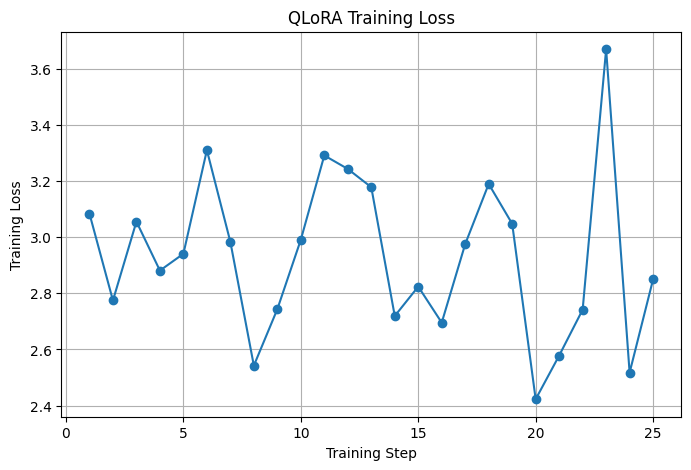


>> [OK] QLoRA loss history analysed.


In [50]:
# Stage 9I: Plot QLoRA training loss

import pandas as pd
import matplotlib.pyplot as plt

qlora_loss_records = [
    {
        "step": entry["step"],
        "loss": entry["loss"]
    }
    for entry in sft_trainer.state.log_history
    if "loss" in entry
]

qlora_loss_df = pd.DataFrame(
    qlora_loss_records
)

print("Stage 9I: QLoRA Loss History")
print("-----------------------------")
print(f"Logged training steps : {len(qlora_loss_df)}")

if len(qlora_loss_df) > 0:

    print(
        f"First logged loss     : "
        f"{qlora_loss_df.iloc[0]['loss']:.4f}"
    )

    print(
        f"Final logged loss     : "
        f"{qlora_loss_df.iloc[-1]['loss']:.4f}"
    )

    print(
        f"Minimum logged loss   : "
        f"{qlora_loss_df['loss'].min():.4f}"
    )

    plt.figure(figsize=(8, 5))

    plt.plot(
        qlora_loss_df["step"],
        qlora_loss_df["loss"],
        marker="o"
    )

    plt.xlabel("Training Step")
    plt.ylabel("Training Loss")
    plt.title("QLoRA Training Loss")
    plt.grid(True)

    plt.show()

print("\n>> [OK] QLoRA loss history analysed.")

#### QLoRA Loss History Observation

Loss was logged at 25 optimizer steps (5 epochs of 5 steps each, with the incomplete final batch of each epoch dropped). The first logged loss was 3.08, the final 2.85 and the minimum 2.42.

The training curve is noisy and shows no clear downward trend. Each point reflects a single update on 4 examples, so a few difficult examples cause large swings, such as the spike to 3.67 at step 23. The validation loss, which decreased at each evaluation (2.895 to 2.780), is the more reliable signal that the adapter learned something. Because the training set is only 23 examples, the loss curve alone cannot show how much the model improved, so the generated answers in the next stage are the main evidence.

#### Stage 9J: Save QLoRA Adapter

The trained LoRA adapter is saved separately from the CPT checkpoint.

This preserves the lightweight instruction-tuning parameters while keeping the CPT model as the underlying domain-adapted base model.

The tokenizer is also saved alongside the adapter so that the same tokenization and chat-formatting configuration can be reused during later inference.

In [51]:
# Stage 9J: Save trained QLoRA adapter

from pathlib import Path

QLORA_ADAPTER_DIR = Path(
    "qlora_finance_adapter"
)

sft_trainer.model.save_pretrained(
    QLORA_ADAPTER_DIR
)

qlora_tokenizer.save_pretrained(
    QLORA_ADAPTER_DIR
)

print("Stage 9J: Adapter Checkpoint")
print("-----------------------------")
print(f"Saved directory: {QLORA_ADAPTER_DIR}")

print("\nFiles:")
for file_path in sorted(
    QLORA_ADAPTER_DIR.iterdir()
):
    print(f" - {file_path.name}")

print("\n>> [OK] QLoRA adapter saved.")

Stage 9J: Adapter Checkpoint
-----------------------------
Saved directory: qlora_finance_adapter

Files:
 - README.md
 - adapter_config.json
 - adapter_model.safetensors
 - merges.txt
 - special_tokens_map.json
 - tokenizer.json
 - tokenizer_config.json
 - vocab.json

>> [OK] QLoRA adapter saved.


#### Adapter Checkpoint Observation

The trained LoRA adapter and tokenizer were saved to `qlora_finance_adapter/`. The adapter is small because it holds only the 1,638,400 LoRA parameters, and it is meant to be loaded on top of the saved CPT model in `cpt_model/`.

## Step 8: QLoRA Evaluation

The trained finance adapter is evaluated using the same three domain prompts used before continued pretraining.

This allows qualitative comparison between:

1. The original pretrained model.
2. The CPT-adapted model.
3. The CPT + QLoRA instruction-tuned model.

The objective is to determine whether QLoRA improves finance-domain instruction following and response quality.

#### Stage 10A: Evaluate the QLoRA Model on Domain Prompts

The trained QLoRA adapter is evaluated using the same three finance-domain prompts used during the earlier baseline and CPT evaluations.

Using identical prompts allows a direct qualitative comparison between the base model, the CPT-adapted model, and the CPT + QLoRA model.

The evaluation focuses on whether QLoRA improves:

- Relevance to the finance-domain question.
- Instruction-following behaviour.
- Response completeness.
- Reduction of repetition.
- Factual consistency with the domain material.

Generation uses deterministic decoding so that the responses are directly comparable across model stages.

In [52]:
# Stage 10A: Evaluate the trained QLoRA adapter

qlora_model = sft_trainer.model
qlora_model.eval()

DOMAIN_PROMPTS = [
    "Explain the risks faced by individual traders in equity derivatives markets.",
    "Explain how UPI has contributed to the growth of digital payments in India.",
    "What is a buy-back of securities and why might a company conduct one?"
]

qlora_outputs = []

for prompt in DOMAIN_PROMPTS:

    messages = [
        {
            "role": "user",
            "content": prompt
        }
    ]

    formatted_prompt = qlora_tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    response = generate_text(qlora_model, qlora_tokenizer, formatted_prompt)

    qlora_outputs.append(response)
    print("Stage 10A: Evaluate the trained QLoRA adapter")
    print("---------------------------------------------\n")
    print("PROMPT:")
    print(prompt)

    print("\n>> QLORA RESPONSE:")
    print(response)

print("\n>> [OK] QLoRA evaluation completed.")

Stage 10A: Evaluate the trained QLoRA adapter
---------------------------------------------

PROMPT:
Explain the risks faced by individual traders in equity derivatives markets.

>> QLORA RESPONSE:
Risk is a major concern for all investors, including individual traders. The primary risk associated with equity derivatives trading is loss of capital due to market movements and leverage. Losses can be substantial if one does not understand the underlying dynamics of the asset classes being traded or fails to manage risk effectively. Additionally, there may also be losses arising from adverse policy actions such as exchange rate fluctuations or changes in regulatory requirements.

The second major risk pertains to counterparty credit risk (CRR). CRR arises when counterparties fail to meet their obligations under contracts involving derivatives transactions. If these parties cannot fulfill their commitments, they could face significant financial losses. For instance, during the Asian Financ

#### QLoRA Evaluation Observation

The QLoRA adapter changed the style of the answers but did not improve their factual accuracy.

- **Format:** On the three prompts, the model begins with a direct answer instead of the exam-style sub-questions seen after CPT.
- **No reliable stopping:** The UPI and buy-back answers continue past the end of the response into invented sections ("III. Regulatory Landscape...", "III.13 How does a buy-out work? Assistant:"). The first answer runs to the generation limit with additional unsupported detail.
- **Hallucination:** The UPI answer names an unsupported person ("Utkarsh Gupta") and overstates UPI's role in international payments. The derivatives answer adds unsupported specifics, such as a 1997 Asian Financial Crisis example.
- **Factual error:** The buy-back is described as an IPO in which a private company raises capital, which is incorrect. The base model, and the CPT model in the Stage 7D run, gave a correct definition on this prompt.

Validation loss decreased during training, but this did not translate into accurate generations. With 23 training examples and 25 optimizer steps, the adapter can at most teach a response format, not new domain facts, and it was applied to a CPT model that already tended to produce confident corpus-style prose. Possible next steps are a larger set of grounded instruction examples and checking that the end-of-text token is kept in the training labels (the padding and end tokens share ID 0).

### Final Model Comparison

| | Base | After CPT | After CPT + QLoRA |
|---|---|---|---|
| Held-out perplexity | 7.97 | 6.63 | not measured |
| "Explain..." prompts | Direct, fluent answers | Continues as exam-style questions | Direct start, but runs on into invented sections |
| Domain facts | Several errors (e.g. UPI "open-source") | Errors remain; invents statistics and concepts | Errors remain; invents a person and unsupported examples |
| Buy-back definition | Correct | Correct definition, then invents a "buy-down" | Incorrect (called an IPO) |
| General knowledge | Intact | Mixed: clear on some prompts, errors on others | Not separately tested |

CPT adapted the model's language statistics to the corpus (held-out perplexity down 16.8%) but did not make it a reliable source of domain facts. QLoRA on 23 examples partly repaired the answer format but not the stopping behaviour or the factual errors. Generation outputs varied between repeated runs of the full pipeline, while perplexity was stable, so the perplexity result is the more reliable evidence. A larger corpus and a larger set of grounded instruction examples would be needed for reliable domain question answering.

## Step 9: Final Submission Verification

The completed pipeline now contains:

- PDF extraction and cleaning.
- Tokenization and packed CPT dataset construction.
- Base-model architecture inspection and baseline inference.
- Continued pretraining and loss analysis.
- Held-out perplexity and catastrophic-forgetting evaluation.
- Finance-domain instruction dataset creation.
- 4-bit QLoRA fine-tuning using the balanced adapter.
- Post-QLoRA evaluation on the original finance prompts.

The following checks verify that the required submission artifacts were generated successfully.

In [53]:
# Stage 11A: Verify submission artifacts

from pathlib import Path
import json

required_files = {
    "Instruction dataset":
        Path("instruction_dataset.jsonl"),

    "Instruction training split":
        Path("instruction_dataset_train.jsonl"),

    "Instruction evaluation split":
        Path("instruction_dataset_eval.jsonl"),

    "CPT model":
        Path("cpt_model"),

    "QLoRA adapter":
        Path("qlora_finance_adapter"),

    "Packed CPT dataset":
        Path("domain_corpus/packed_dataset.parquet"),
}

print("Stage 11A: Submission Artifact Verification")
print("--------------------------------------------")

all_present = True

for name, path in required_files.items():

    exists = path.exists()

    print(
        f"{name:<30}: "
        f"{'OK' if exists else 'MISSING'}"
    )

    if not exists:
        all_present = False


# Cleaned .txt corpus
cleaned_txt_files = sorted(
    Path("domain_corpus").glob("*.txt")
)

print(
    f"{'Cleaned corpus files':<30}: "
    f"{len(cleaned_txt_files)} found"
)


# Count JSONL records
def count_jsonl(path):
    if not path.exists():
        return 0

    with open(path, encoding="utf-8") as f:
        return sum(
            1 for line in f
            if line.strip()
        )


print("\nInstruction Dataset")
print("-------------------")

print(
    "Full dataset :",
    count_jsonl(
        Path("instruction_dataset.jsonl")
    )
)

print(
    "Training set :",
    count_jsonl(
        Path("instruction_dataset_train.jsonl")
    )
)

print(
    "Evaluation set:",
    count_jsonl(
        Path("instruction_dataset_eval.jsonl")
    )
)


assert len(cleaned_txt_files) == 10

assert count_jsonl(
    Path("instruction_dataset.jsonl")
) == 29

assert count_jsonl(
    Path("instruction_dataset_train.jsonl")
) == 23

assert count_jsonl(
    Path("instruction_dataset_eval.jsonl")
) == 6

assert all_present


print(
    "\n>> [OK] Required assignment artifacts "
    "are present."
)

Stage 11A: Submission Artifact Verification
--------------------------------------------
Instruction dataset           : OK
Instruction training split    : OK
Instruction evaluation split  : OK
CPT model                     : OK
QLoRA adapter                 : OK
Packed CPT dataset            : OK
Cleaned corpus files          : 10 found

Instruction Dataset
-------------------
Full dataset : 29
Training set : 23
Evaluation set: 6

>> [OK] Required assignment artifacts are present.
